In [ ]:
import kagglehub
import os

kagglehub.login()

path = kagglehub.competition_download("playground-series-s6e4")

train_csv_path = os.path.join(path, "train.csv")
test_csv_path = os.path.join(path, "test.csv")
sample_submission_csv_path = os.path.join(path, "sample_submission.csv")

print(train_csv_path)

C:\Users\ASUS\.cache\kagglehub\competitions\playground-series-s6e4\train.csv


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Load CSV and check head

In [ ]:
train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)
train_df.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


Set index to ID ,id has no predictive signal

In [ ]:
train_df.set_index("id", inplace = True)
test_df.set_index("id", inplace = True)

In [ ]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Soil_Type                630000 non-null  str    
 1   Soil_pH                  630000 non-null  float64
 2   Soil_Moisture            630000 non-null  float64
 3   Organic_Carbon           630000 non-null  float64
 4   Electrical_Conductivity  630000 non-null  float64
 5   Temperature_C            630000 non-null  float64
 6   Humidity                 630000 non-null  float64
 7   Rainfall_mm              630000 non-null  float64
 8   Sunlight_Hours           630000 non-null  float64
 9   Wind_Speed_kmh           630000 non-null  float64
 10  Crop_Type                630000 non-null  str    
 11  Crop_Growth_Stage        630000 non-null  str    
 12  Season                   630000 non-null  str    
 13  Irrigation_Type          630000 non-null  str    
 14  Water_Source   

In [ ]:
train_df.describe()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


EDA

Checking Class Imbalace of Target Variable

<Axes: xlabel='Irrigation_Need'>

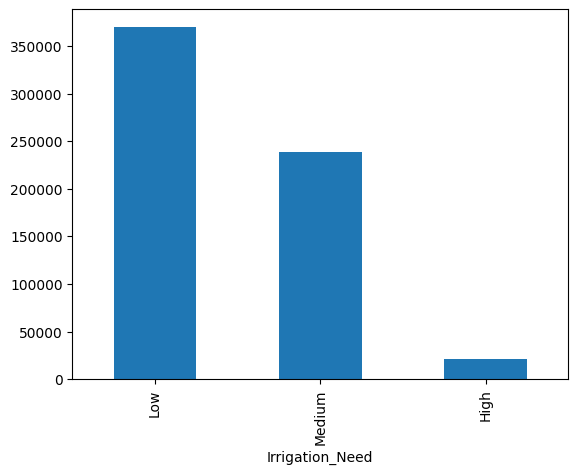

In [ ]:
train_df['Irrigation_Need'].value_counts().plot(kind='bar')

High Class imbalance ,use stratified k fold and also specific params[class_weight] in gradient boosting models,
Not using SMOTE Here

Check Duplicates and Nulls

In [ ]:
train_df.duplicated().sum()

np.int64(0)

In [ ]:
train_df.isnull().sum()

Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

Initial Preprocessing

Map target column to numerical values

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
target_encoder =  OrdinalEncoder(handle_unknown= 'use_encoded_value', unknown_value = -1, 
                                 categories=[['Low', 'Medium', 'High']])
train_df['Irrigation_Need'] = target_encoder.fit_transform(train_df[['Irrigation_Need']]) + 1

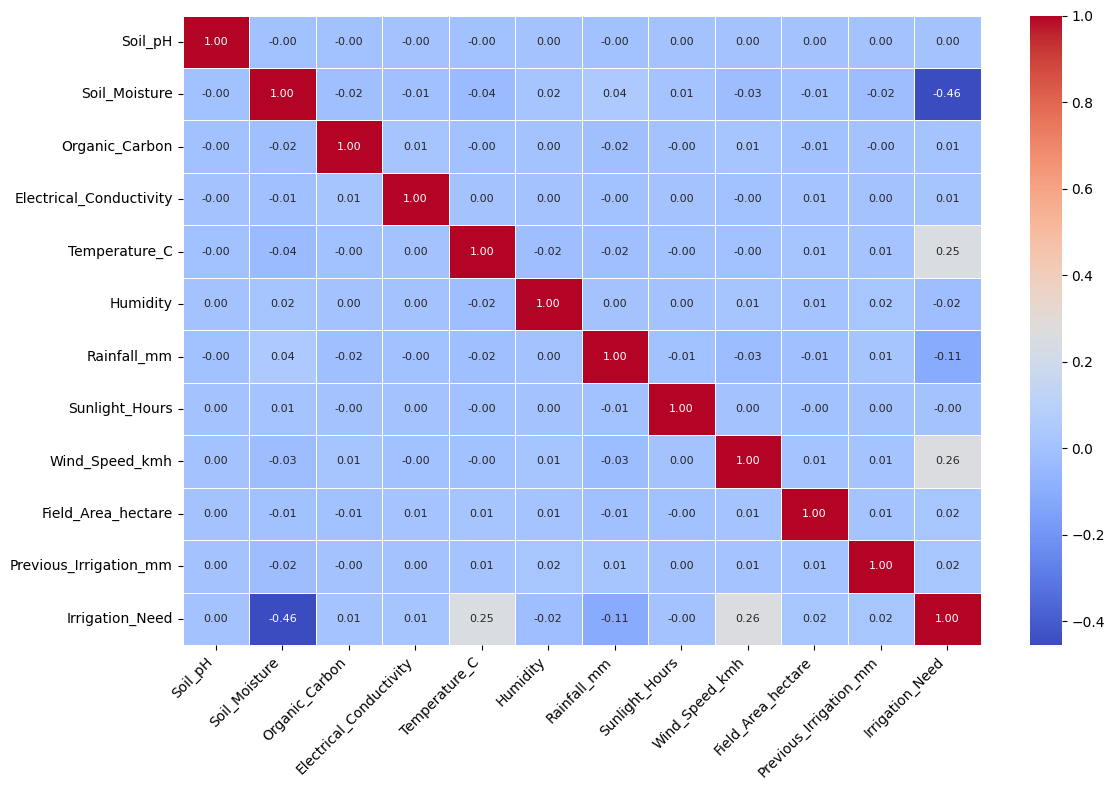

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    train_df.select_dtypes(include=np.number).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size": 8}
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

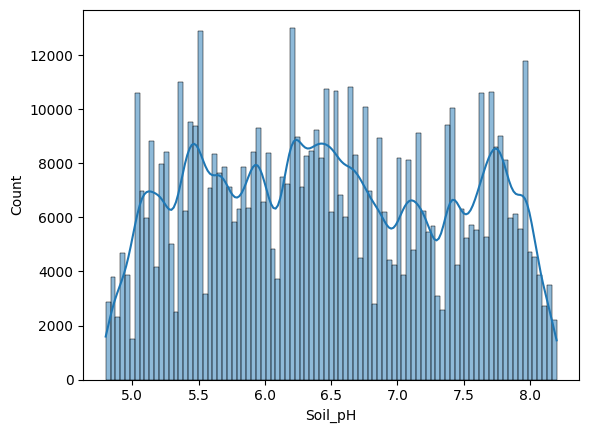

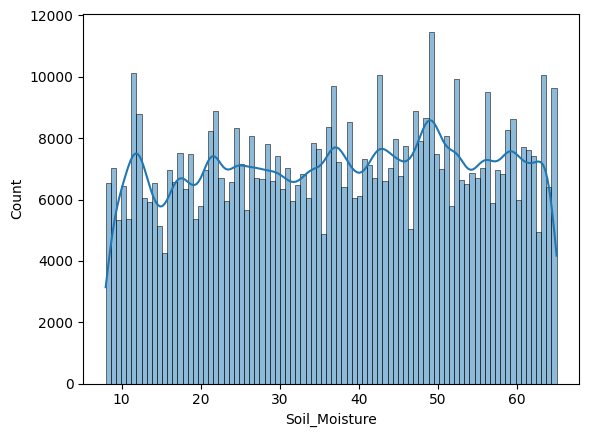

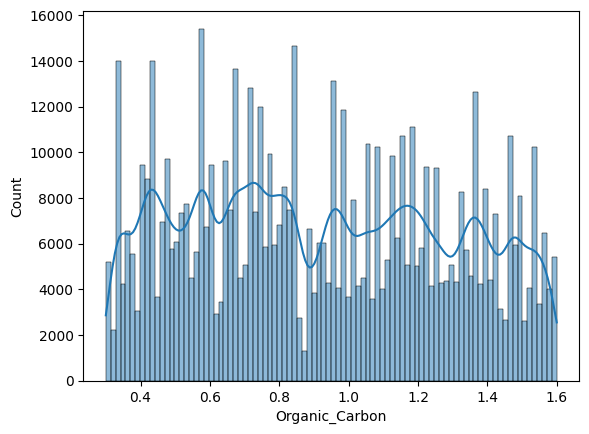

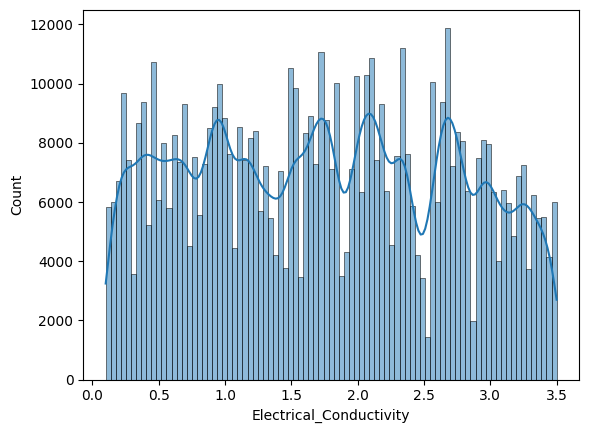

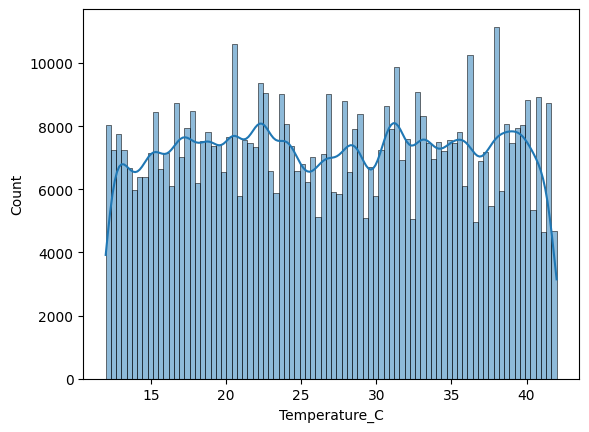

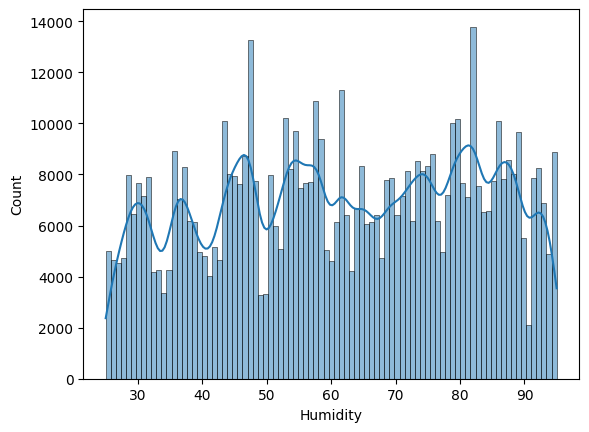

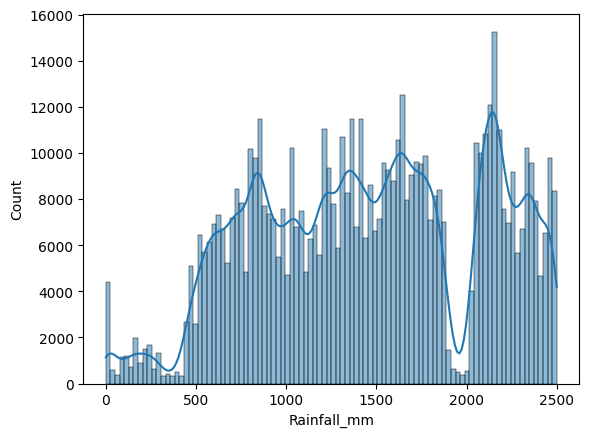

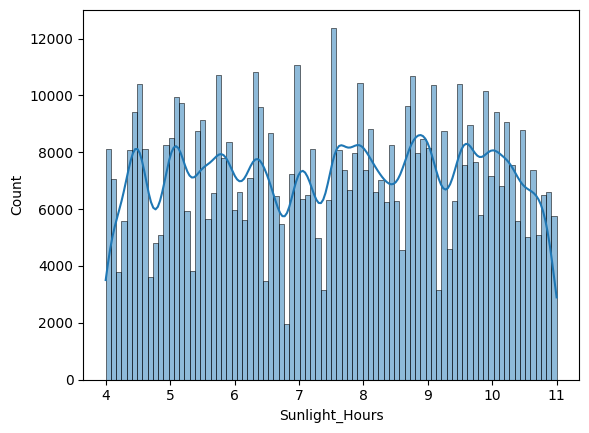

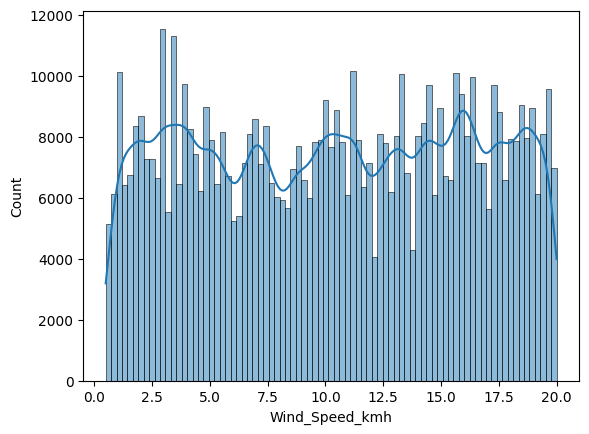

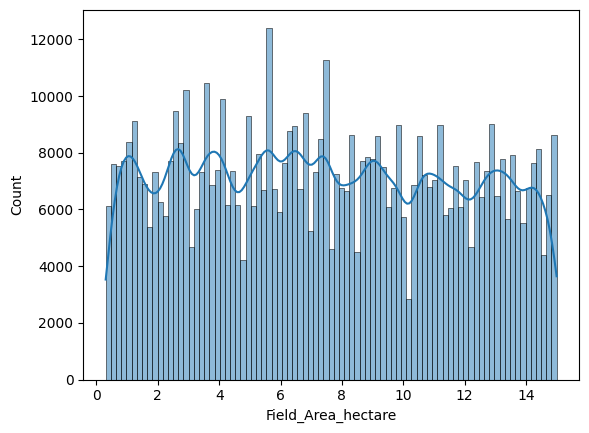

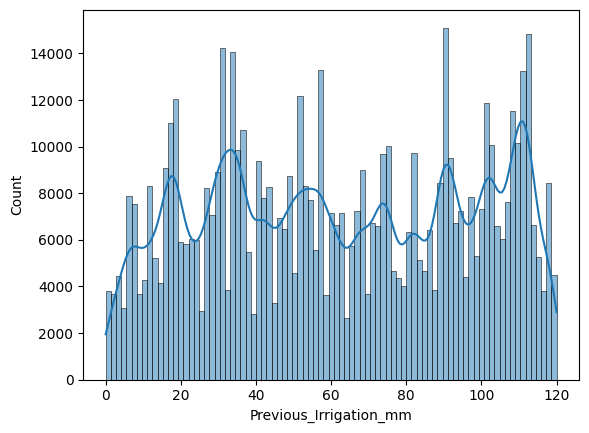

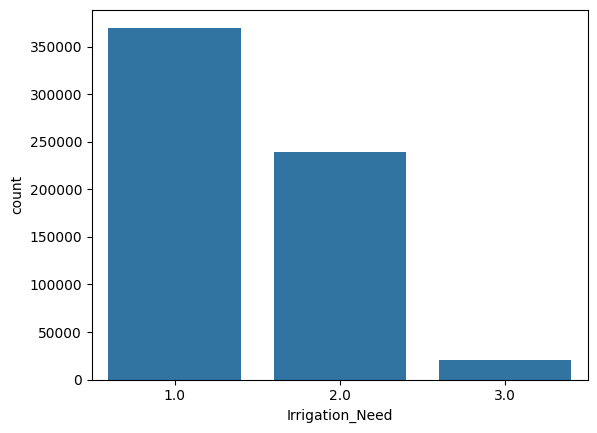

In [ ]:
for i in train_df.columns:
    if train_df[i].dtype == 'object':
        sns.countplot(data=train_df, x = i)
        plt.show()
    elif train_df[i].dtype in ['int64', 'float64']:
        if train_df[i].nunique() < 10:
            sns.countplot(data=train_df, x = i)
            plt.show()
        else:
            sns.histplot(data=train_df, x = i, kde=True)
            plt.show()

Ensure all outputs of all transformers are in Dataframe

In [ ]:
from sklearn import set_config
set_config(transform_output = 'pandas')

Split Train/Test FIRST (before feature engineering to prevent leakage)

In [ ]:
from sklearn.model_selection import train_test_split

train_raw_features = train_df.drop(columns=['Irrigation_Need']).copy()
train_raw_target = train_df['Irrigation_Need'].copy()

x_train_raw, x_test_raw, y_train, y_test = train_test_split(
    train_raw_features, train_raw_target,
    test_size=0.1, stratify=train_raw_target,
    shuffle=True, random_state=11
)

print(f"Train split shape: {x_train_raw.shape}")
print(f"Test split shape: {x_test_raw.shape}")

Train split shape: (567000, 19)
Test split shape: (63000, 19)


Feature Engineering

In [ ]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class IrrigationFeatureEngineer(BaseEstimator, TransformerMixin):
 
    def __init__(self):
        self.soil_moisture_means_ = {}
        self.crop_season_means_ = {}
        self.region_means_ = {}
        self.crop_type_means_ = {}

    def fit(self, X, y=None):
        df = X.copy()

        self.soil_moisture_means_ = df.groupby(['Region', 'Soil_Type'])['Soil_Moisture'].mean().to_dict()

        # Target encodings: computed only if y is provided (fold-local during CV)
        if y is not None:
            df['Irrigation_Need'] = y
            self.crop_season_means_ = df.groupby(['Crop_Type', 'Season'])['Irrigation_Need'].mean().to_dict()
            self.region_means_ = df.groupby('Region')['Irrigation_Need'].mean().to_dict()
            self.crop_type_means_ = df.groupby('Crop_Type')['Irrigation_Need'].mean().to_dict()

        return self
 
    def transform(self, X, y=None):
        fe = X.copy()
 
        fe['Mulching_Used'] = fe['Mulching_Used'].map({'Yes': 1, 'No': 0})
        fe['Growth_Stage_Ord'] = fe['Crop_Growth_Stage'].map({'Sowing': 1, 'Vegetative': 2, 'Flowering': 3, 'Maturity': 4})
        fe['Season_Ord'] = fe['Season'].map({'Kharif': 1, 'Rabi': 2, 'Zaid': 3})
 
        # BUG 4 FIX: Merge Kc lookup table FIRST and reset index to prevent misalignment
        kc_df = pd.DataFrame([
            ('Wheat', 'Sowing', 0.40), ('Wheat', 'Vegetative', 0.70), ('Wheat', 'Flowering', 1.15), ('Wheat', 'Maturity', 0.25),
            ('Rice', 'Sowing', 1.05), ('Rice', 'Vegetative', 1.20), ('Rice', 'Flowering', 1.20), ('Rice', 'Maturity', 0.90),
            ('Sugarcane', 'Sowing', 0.40), ('Sugarcane', 'Vegetative', 0.95), ('Sugarcane', 'Flowering', 1.25), ('Sugarcane', 'Maturity', 0.75),
            ('Maize', 'Sowing', 0.30), ('Maize', 'Vegetative', 0.70), ('Maize', 'Flowering', 1.20), ('Maize', 'Maturity', 0.35),
            ('Cotton', 'Sowing', 0.45), ('Cotton', 'Vegetative', 0.75), ('Cotton', 'Flowering', 1.15), ('Cotton', 'Maturity', 0.70),
            ('Soybean', 'Sowing', 0.40), ('Soybean', 'Vegetative', 0.80), ('Soybean', 'Flowering', 1.15), ('Soybean', 'Maturity', 0.50),
        ], columns=['Crop_Type', 'Crop_Growth_Stage', 'Kc'])

        fe = fe.merge(kc_df, on=['Crop_Type', 'Crop_Growth_Stage'], how='left').reset_index(drop=True)
        fe['Kc'] = fe['Kc'].fillna(0.85)
 
        # Now capture variables with aligned index AFTER merge
        T = fe['Temperature_C']
        RH = fe['Humidity']
        es = 0.6108 * np.exp((17.27 * T) / (T + 237.3))
        ea = es * (RH / 100)
        fe['VPD'] = es - ea
 
        delta = 4098 * es / (T + 237.3) ** 2
        gamma = 0.067
        u2 = fe['Wind_Speed_kmh'] / 3.6
        Rn_proxy = fe['Sunlight_Hours'] * 2.0
        denom = (delta + gamma * (1 + 0.34 * u2))
        fe['ETo_approx'] = (0.408 * Rn_proxy * delta + gamma * (900 / (T + 273)) * u2 * fe['VPD']) / denom
        fe['ETc'] = fe['Kc'] * fe['ETo_approx']
 
        # ...existing code...(all other engineered features)
        R = fe['Rainfall_mm']
        fe['Effective_Rainfall'] = np.where(R <= 75, R * 0.8, 60 + 0.1 * (R - 75))
        fe['Net_Irrigation_Req'] = np.maximum(fe['ETc'] - fe['Effective_Rainfall'], 0)
        fe['Soil_Water_Stress_Ks'] = fe['Soil_Moisture'] / 50.0
        fe['ETc_stressed'] = fe['ETc'] * fe['Soil_Water_Stress_Ks']
        fe['Moisture_Deficit'] = 100 - fe['Soil_Moisture']
        fe['Moisture_Deficit_Ratio'] = fe['Moisture_Deficit'] / (fe['Rainfall_mm'] + 1)
        fe['Water_Retention_Index'] = fe['Organic_Carbon'] / (fe['Electrical_Conductivity'] + 0.01)
        fe['Salt_Stress'] = (fe['Electrical_Conductivity'] > 4).astype(float)
        fe['pH_Deviation'] = np.abs(fe['Soil_pH'] - 6.5)
        fe['pH_Acidic_Flag'] = (fe['Soil_pH'] < 5.5).astype(float)
        fe['pH_Alkaline_Flag'] = (fe['Soil_pH'] > 7.5).astype(float)
        fe['Temp_x_Wind'] = T * fe['Wind_Speed_kmh']
        fe['Temp_x_VPD'] = T * fe['VPD']
        fe['Sun_x_Wind'] = fe['Sunlight_Hours'] * fe['Wind_Speed_kmh']
        fe['Heat_Index'] = T + 0.33 * ea - 0.7 * u2 - 4.0
        fe['Rain_Retention'] = fe['Soil_Moisture'] / (fe['Rainfall_mm'] + 1)
        fe['Rain_per_Area'] = fe['Rainfall_mm'] / (fe['Field_Area_hectare'] + 1e-6)
        fe['PrevIrr_per_Area'] = fe['Previous_Irrigation_mm'] / (fe['Field_Area_hectare'] + 1e-6)
        eff_map = {'Drip': 0.90, 'Sprinkler': 0.75, 'Canal': 0.55, 'Rainfed': 1.00}
        fe['Irrigation_Efficiency'] = fe['Irrigation_Type'].map(eff_map)
        fe['Adjusted_Prev_Irrigation'] = fe['Previous_Irrigation_mm'] * fe['Irrigation_Efficiency']
        source_map = {'River': 1.0, 'Reservoir': 0.9, 'Canal': 0.75, 'Rainwater': 0.5, 'Groundwater': 0.8}
        fe['Source_Reliability'] = fe['Water_Source'].map(source_map)

        fe['RegionSoil_AvgMoisture'] = pd.Series(list(zip(fe['Region'], fe['Soil_Type']))).map(self.soil_moisture_means_)
 
        # Restore target-encoded features (fold-safe if encoder.fit(X, y) was called fold-locally)
        global_mean = np.mean(list(self.crop_type_means_.values())) if self.crop_type_means_ else np.nan
        fe['CropSeason_MeanIrr'] = pd.Series(list(zip(fe['Crop_Type'], fe['Season']))).map(self.crop_season_means_)
        fe['CropSeason_MeanIrr'] = fe['CropSeason_MeanIrr'].fillna(global_mean)
        fe['Region_MeanIrr'] = fe['Region'].map(self.region_means_)
        fe['Crop_Type_TargetEnc'] = fe['Crop_Type'].map(self.crop_type_means_).fillna(global_mean)
        
        # BUG 3 FIX: Removed duplicate Region_TargetEnc (was identical to Region_MeanIrr)
        # Added new informative feature: ET0_minus_EffRain (moisture deficit from ET perspective)
        fe['ET0_minus_EffRain'] = fe['ETo_approx'] - fe['Effective_Rainfall']

        drop_cols = ['Crop_Type', 'Region', 'Crop_Growth_Stage']
        fe.drop(columns=[c for c in drop_cols if c in fe.columns], inplace=True)
 
        return fe


In [ ]:
pd.set_option('display.max_columns', None)
print("Fitting feature engineer on training data only...")
fe_df = IrrigationFeatureEngineer()
x_train = fe_df.fit_transform(x_train_raw, y_train)
x_test = fe_df.transform(x_test_raw)

print(f"Training features shape: {x_train.shape}")
print(f"Test features shape: {x_test.shape}")

Fitting feature engineer on training data only...
Training features shape: (567000, 48)
Test features shape: (63000, 48)


In [ ]:
x_train.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Growth_Stage_Ord,Season_Ord,VPD,ETo_approx,Kc,ETc,Effective_Rainfall,Net_Irrigation_Req,Soil_Water_Stress_Ks,ETc_stressed,Moisture_Deficit,Moisture_Deficit_Ratio,Water_Retention_Index,Salt_Stress,pH_Deviation,pH_Acidic_Flag,pH_Alkaline_Flag,Temp_x_Wind,Temp_x_VPD,Sun_x_Wind,Heat_Index,Rain_Retention,Rain_per_Area,PrevIrr_per_Area,Irrigation_Efficiency,Adjusted_Prev_Irrigation,Source_Reliability,RegionSoil_AvgMoisture,CropSeason_MeanIrr,Region_MeanIrr,Crop_Type_TargetEnc,Region_TargetEnc
0,Silt,7.64,57.47,1.22,3.49,12.38,86.70,871.21,6.69,15.89,Rabi,Drip,Rainwater,14.76,0,71.06,2.0,2,0.191267,2.649744,0.85,2.252283,139.621,0.0,1.1494,2.588774,42.53,0.048761,0.348571,0.0,1.14,0.0,1.0,NaN,NaN,106.3041,NaN,0.065890,59.025064,4.814363,0.90,63.954,0.5,37.395052,1.445675,1.441820,1.452205,1.441820
1,Sandy,5.06,15.78,1.26,1.97,33.56,64.71,1414.14,10.77,18.21,Rabi,Rainfed,Groundwater,1.71,1,33.29,2.0,2,1.831665,9.256316,0.70,6.479421,193.914,0.0,0.3156,2.044905,84.22,0.059514,0.636364,0.0,1.44,1.0,0.0,NaN,NaN,196.1217,NaN,0.011151,826.981973,19.467825,1.00,33.290,0.8,36.833846,1.421537,1.458365,1.435128,1.458365
2,Sandy,6.84,44.91,0.84,3.47,33.85,76.86,2187.80,9.74,8.86,Kharif,Rainfed,Reservoir,14.84,0,103.64,1.0,1,1.220634,7.018177,0.85,5.965451,271.280,0.0,0.8982,5.358168,55.09,0.025169,0.241379,0.0,0.34,0.0,0.0,238.9542,32.920496,86.2964,23.304506,0.020518,147.425866,6.983827,1.00,103.640,0.9,37.033485,1.469711,1.434599,1.452205,1.434599
3,Loamy,7.20,30.06,0.96,1.14,30.48,61.47,1356.96,9.67,15.43,Kharif,Drip,Rainwater,6.35,1,1.03,2.0,1,1.680406,8.209585,0.70,5.746710,188.196,0.0,0.6012,3.454922,69.94,0.051504,0.834783,0.0,0.70,0.0,0.0,205.5276,22.383004,149.2081,9.181581,0.022136,213.694455,0.162205,0.90,0.927,0.5,37.602455,1.448133,1.441820,1.435128,1.441820
4,Sandy,6.25,55.57,0.42,1.24,30.76,61.52,1764.78,5.19,10.79,Kharif,Sprinkler,Rainwater,5.82,0,76.92,3.0,1,1.705269,5.373423,1.15,6.179436,228.978,0.0,1.1114,6.867826,44.43,0.025162,0.336000,0.0,0.25,0.0,0.0,218.1738,34.480531,56.0001,14.222111,0.031471,303.226752,13.216493,0.75,57.690,0.5,37.037880,1.464960,1.448909,1.449461,1.448909


Exploratory Feature Ranking (Mutual Information - Optional)

In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("EXPLORATORY: Computing Mutual Information Scores")
print("="*80)
print("PURPOSE: Rank features by information gain (training data only)")
print("LEAKAGE-FREE: No preprocessing leakage - computed on raw engineered features")
print("NOTE: Results are exploratory; final feature selection done within CV folds")

try:
    x_train_mi = x_train.copy()
    y_train_mi = y_train.copy()
    
    # Identify column types for proper handling
    categorical_cols = x_train_mi.select_dtypes(include=["object", "category"]).columns.tolist()
    numeric_cols = x_train_mi.select_dtypes(include=["int64", "int32", "float64", "float32", "bool"]).columns.tolist()
    
    # Impute missing values in numeric features
    if numeric_cols:
        num_imputer = SimpleImputer(strategy="median")
        x_train_mi[numeric_cols] = num_imputer.fit_transform(x_train_mi[numeric_cols])
    
    # Impute missing values in categorical features
    if categorical_cols:
        cat_imputer = SimpleImputer(strategy="most_frequent")
        x_train_mi[categorical_cols] = cat_imputer.fit_transform(x_train_mi[categorical_cols])
    
    # Encode categorical features as numeric codes
    for col in categorical_cols:
        x_train_mi[col] = pd.Categorical(x_train_mi[col]).codes
    
    # Compute mutual information
    print(f"Computing MI for {x_train_mi.shape[1]} features from {x_train_mi.shape[0]} samples...")
    mi_scores = mutual_info_classif(
        x_train_mi,
        y_train_mi,
        discrete_features=x_train_mi.columns.isin(categorical_cols),
        random_state=11
    )
    
    mi_scores = pd.Series(mi_scores, index=x_train_mi.columns).sort_values(ascending=False)
    mi_ranked_columns = mi_scores.index.tolist()
    
    print(f"Status: Complete | Features with MI > 0: {(mi_scores > 0).sum()}/{len(mi_scores)}")
    print("Top 20 Features by Mutual Information:")
    print(mi_scores.head(20).to_string())
    print("Features ranked and stored in 'mi_ranked_columns' for reference")
    
except Exception as e:
    import traceback
    print(f"Error computing MI: {str(e)}")
    print(f"Traceback: {traceback.format_exc()}")
    print("Proceeding without MI ranking (no leakage introduced)")
    mi_ranked_columns = x_train.columns.tolist()

EXPLORATORY: Computing Mutual Information Scores
PURPOSE: Rank features by information gain (training data only)
LEAKAGE-FREE: No preprocessing leakage - computed on raw engineered features
NOTE: Results are exploratory; final feature selection done within CV folds
Computing MI for 48 features from 567000 samples...
Status: Complete | Features with MI > 0: 48/48
Top 20 Features by Mutual Information:
Moisture_Deficit            0.205445
Soil_Water_Stress_Ks        0.205399
Soil_Moisture               0.204913
Rainfall_mm                 0.188654
Effective_Rainfall          0.188630
Kc                          0.135169
Growth_Stage_Ord            0.115570
Mulching_Used               0.103207
Rain_Retention              0.100147
Moisture_Deficit_Ratio      0.075597
Temperature_C               0.073739
ETc                         0.070199
Wind_Speed_kmh              0.063515
Previous_Irrigation_mm      0.051623
Humidity                    0.048214
Adjusted_Prev_Irrigation    0.047998
Sun_

Primary Data Preprocessing (Now Integrated into CV Loop)

In [ ]:
print("="*80)
print("NOTE: Preprocessing is now integrated into the StratifiedKFold loop below")
print("to prevent data leakage. Feature engineering, preprocessing, and selection")
print("are all performed fold-locally using only training data for each fold.")
print("="*80)


NOTE: Preprocessing is now integrated into the StratifiedKFold loop below
to prevent data leakage. Feature engineering, preprocessing, and selection
are all performed fold-locally using only training data for each fold.


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Define feature groups (reused in each fold)
soil_numeric = ['Soil_pH', 'Organic_Carbon', 'Electrical_Conductivity']
moisture_numeric = ['Soil_Moisture', 'Rainfall_mm', 'Previous_Irrigation_mm']
climate_numeric = ['Temperature_C', 'Humidity', 'Wind_Speed_kmh', 'Sunlight_Hours']
engineered_numeric = [
    'Moisture_Deficit', 'Moisture_Deficit_Ratio', 'Effective_Rainfall',
    'Net_Irrigation_Req', 'Soil_Water_Stress_Ks', 'ETc_stressed',
    'Water_Retention_Index', 'Rain_Retention', 'Rain_per_Area',
    'PrevIrr_per_Area', 'Temp_x_Wind', 'Temp_x_VPD', 'Sun_x_Wind',
    'Heat_Index', 'VPD', 'ETo_approx', 'ETc', 'Kc'
]
ordinal_features = ['Mulching_Used', 'Growth_Stage_Ord', 'Season_Ord']
target_encoded = ['Crop_Type_TargetEnc', 'Region_TargetEnc', 'CropSeason_MeanIrr', 'Region_MeanIrr', 'RegionSoil_AvgMoisture']
categorical_features = ['Season', 'Soil_Type', 'Water_Source', 'Irrigation_Type']
flag_features = ['pH_Acidic_Flag', 'pH_Alkaline_Flag', 'Salt_Stress']

print("\n" + "="*80)
print("PROGRESSIVE FEATURE SELECTION WITH STRATIFIED K-FOLD CV (LEAKAGE-FREE)")
print("="*80)
print("IMPORTANT: Feature engineering, preprocessing, and selection are now done")
print("INSIDE each fold using ONLY the training data for that fold.\n")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)

# Separate feature importance across folds for final consensus
all_fold_importances = {name: [] for name in ['XGBoost', 'LightGBM', 'RandomForest']}
all_fold_importance_series = {name: [] for name in ['XGBoost', 'LightGBM', 'RandomForest']}
all_fold_aucs = {name: [] for name in ['XGBoost', 'LightGBM', 'RandomForest']}
progressive_auc_by_feature = {}

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(x_train_raw, y_train)):
    print(f"\n{'='*80}")
    print(f"FOLD {fold_idx + 1}/5")
    print(f"{'='*80}")

    # Split this fold into train/val
    x_fold_train_raw = x_train_raw.iloc[train_idx]
    x_fold_val_raw = x_train_raw.iloc[val_idx]
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # ========== STEP 1: FEATURE ENGINEERING (fold-local) ==========
    fe_fold = IrrigationFeatureEngineer()
    x_fold_train_fe = fe_fold.fit_transform(x_fold_train_raw, y_fold_train)  # FIT on train fold only
    x_fold_val_fe = fe_fold.transform(x_fold_val_raw)  # TRANSFORM val fold using train fold's statistics

    # ========== STEP 2: PREPROCESSING (fold-local) ==========
    preprocessor_fold = ColumnTransformer(
        transformers=[
            ('soil', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), soil_numeric),
            ('moisture', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', RobustScaler(quantile_range=(10, 90)))]), moisture_numeric),
            ('climate', Pipeline([('imputer', SimpleImputer(strategy='median')), ('transformer', PowerTransformer(method='yeo-johnson'))]), climate_numeric),
            ('engineered', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', RobustScaler(quantile_range=(5, 95)))]), engineered_numeric),
            ('ordinal', Pipeline([('imputer', SimpleImputer(strategy='most_frequent'))]), ordinal_features),
            ('target_encoded', Pipeline([('imputer', SimpleImputer(strategy='mean')), ('scaler', StandardScaler())]), target_encoded),
            ('ohe', Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical_features),
            ('flags', 'passthrough', flag_features)
        ],
        remainder='drop'
    )
    x_fold_train_pp = preprocessor_fold.fit_transform(x_fold_train_fe)  # FIT on train fold only
    x_fold_val_pp = preprocessor_fold.transform(x_fold_val_fe)  # TRANSFORM val fold

    # ========== STEP 3: FEATURE SELECTION (fold-local) ==========
    selector_fold = VarianceThreshold(threshold=0.01)
    x_fold_train_sel = selector_fold.fit_transform(x_fold_train_pp)  # FIT on train fold only
    x_fold_val_sel = selector_fold.transform(x_fold_val_pp)  # TRANSFORM val fold

    # Keep selected feature names for aligned importance aggregation.
    selected_feature_names = preprocessor_fold.get_feature_names_out()[selector_fold.get_support()].tolist()

    if not hasattr(x_fold_train_sel, 'iloc'):
        x_fold_train_sel = pd.DataFrame(x_fold_train_sel, columns=selected_feature_names, index=x_fold_train_fe.index)
        x_fold_val_sel = pd.DataFrame(x_fold_val_sel, columns=selected_feature_names, index=x_fold_val_fe.index)

    print(f"Fold {fold_idx + 1}: After variance selection, features: {x_fold_train_sel.shape[1]}")

    # ========== STEP 4a: GET FEATURE IMPORTANCES & RANK FEATURES ==========
    y_fold_train_model = (y_fold_train - 1).astype(int)
    y_fold_val_model = (y_fold_val - 1).astype(int)

    # Quick feature importance ranking from XGBoost (fast for ranking)
    temp_xgb = XGBClassifier(n_estimators=50, max_depth=5, learning_rate=0.1,
                             random_state=11, eval_metric='mlogloss', verbosity=0,
                             scale_pos_weight=1, n_jobs=-1)
    temp_xgb.fit(x_fold_train_sel, y_fold_train_model)
    feature_ranks = np.argsort(temp_xgb.feature_importances_)[::-1]  # Rank features by importance

    # ========== STEP 4b: PROGRESSIVE FEATURE SELECTION ==========
    print(f"\nFold {fold_idx + 1}: Progressive Feature Selection")
    print(f"{'Feature Count':>15} | {'XGBoost':>10} | {'LightGBM':>10} | {'RandomForest':>12}")
    print("-" * 55)

    max_features = x_fold_train_sel.shape[1]
    feature_steps = list(range(10, max_features + 1, 5))
    if feature_steps[-1] != max_features:
        feature_steps.append(max_features)

    fold_progressive_results = {n_feat: {'XGBoost': [], 'LightGBM': [], 'RandomForest': []} for n_feat in feature_steps}

    for n_features in feature_steps:
        # Select top N features by importance
        selected_feat_indices = feature_ranks[:n_features]
        x_fold_train_topn = x_fold_train_sel.iloc[:, selected_feat_indices]
        x_fold_val_topn = x_fold_val_sel.iloc[:, selected_feat_indices]

        # Train models on top N features
        fold_models = {
            'XGBoost': XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                                     random_state=11, eval_metric='mlogloss', verbosity=0,
                                     scale_pos_weight=1, n_jobs=-1),
            'LightGBM': LGBMClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                                       random_state=11, verbose=-1, is_unbalance=True, n_jobs=-1),
            'RandomForest': RandomForestClassifier(n_estimators=100, max_depth=10,
                                                   random_state=11, n_jobs=-1, class_weight='balanced')
        }

        fold_auc_summary = {}
        for model_name, model in fold_models.items():
            model.fit(x_fold_train_topn, y_fold_train_model)
            y_pred_proba = model.predict_proba(x_fold_val_topn)

            try:
                auc_fold = roc_auc_score(y_fold_val_model, y_pred_proba, multi_class='ovr', average='macro')
                fold_auc_summary[model_name] = auc_fold
                fold_progressive_results[n_features][model_name].append(auc_fold)
            except Exception as e:
                fold_auc_summary[model_name] = np.nan

        # Print row
        print(f"{n_features:>15} | {fold_auc_summary['XGBoost']:>10.4f} | {fold_auc_summary['LightGBM']:>10.4f} | {fold_auc_summary['RandomForest']:>12.4f}")

        # Store per-feature-count AUCs for cross-fold averaging.
        if n_features not in progressive_auc_by_feature:
            progressive_auc_by_feature[n_features] = {name: [] for name in fold_models.keys()}

        for model_name in fold_models.keys():
            progressive_auc_by_feature[n_features][model_name].append(fold_auc_summary[model_name])

        # Store importances from ALL models at full feature set
        if n_features == max_features:
            for imp_model_name, imp_model in fold_models.items():
                if hasattr(imp_model, 'feature_importances_'):
                    all_fold_importances[imp_model_name].append(imp_model.feature_importances_)
                    all_fold_importance_series[imp_model_name].append(
                        pd.Series(imp_model.feature_importances_, index=selected_feature_names)
                    )

print(f"\n{'='*80}")
print("PROGRESSIVE FEATURE SELECTION - CROSS-FOLD AVERAGE")
print(f"{'='*80}")

# Organize results by feature count
feature_count_results = {}
for n_feat, model_dict in progressive_auc_by_feature.items():
    feature_count_results[n_feat] = {name: [] for name in ['XGBoost', 'LightGBM', 'RandomForest']}
    for model_name in ['XGBoost', 'LightGBM', 'RandomForest']:
        feature_count_results[n_feat][model_name] = model_dict[model_name]

# Print progressive results
print(f"\n{'Feature Count':>15} | {'XGBoost':>14} | {'LightGBM':>14} | {'RandomForest':>14}")
print("-" * 60)

progressive_summary = []
for n_features in sorted(feature_count_results.keys()):
    xgb_aucs = feature_count_results[n_features]['XGBoost']
    lgb_aucs = feature_count_results[n_features]['LightGBM']
    rf_aucs = feature_count_results[n_features]['RandomForest']

    xgb_mean = np.mean(xgb_aucs)
    lgb_mean = np.mean(lgb_aucs)
    rf_mean = np.mean(rf_aucs)

    print(f"{n_features:>15} | {xgb_mean:>8.4f}±{np.std(xgb_aucs):>4.4f} | {lgb_mean:>8.4f}±{np.std(lgb_aucs):>4.4f} | {rf_mean:>8.4f}±{np.std(rf_aucs):>4.4f}")

    progressive_summary.append({
        'n_features': n_features,
        'XGBoost': xgb_mean,
        'LightGBM': lgb_mean,
        'RandomForest': rf_mean,
        'Avg_AUC': np.mean([xgb_mean, lgb_mean, rf_mean])
    })

# Find optimal feature count
optimal_row = max(progressive_summary, key=lambda x: x['Avg_AUC'])
print(f"\n{'='*60}")
print(f"OPTIMAL FEATURE COUNT: {optimal_row['n_features']} features")
print(f"Average AUC: {optimal_row['Avg_AUC']:.4f}")
print(f"{'='*60}")



PROGRESSIVE FEATURE SELECTION WITH STRATIFIED K-FOLD CV (LEAKAGE-FREE)
IMPORTANT: Feature engineering, preprocessing, and selection are now done
INSIDE each fold using ONLY the training data for that fold.


FOLD 1/5
Fold 1: After variance selection, features: 53

Fold 1: Progressive Feature Selection
  Feature Count |    XGBoost |   LightGBM | RandomForest
-------------------------------------------------------
             10 |     0.9949 |     0.9954 |       0.9924
             15 |     0.9950 |     0.9955 |       0.9891
             20 |     0.9950 |     0.9955 |       0.9890
             25 |     0.9950 |     0.9955 |       0.9885
             30 |     0.9950 |     0.9955 |       0.9863
             35 |     0.9950 |     0.9955 |       0.9849
             40 |     0.9950 |     0.9955 |       0.9840
             45 |     0.9950 |     0.9955 |       0.9821
             50 |     0.9950 |     0.9955 |       0.9834
             53 |     0.9950 |     0.9955 |       0.9820

FOLD 2/5
Fol

KeyboardInterrupt: 

## Aggregated Feature Importance Across All Folds

Averaging feature importances from all folds for consensus ranking:


CONSENSUS FEATURE IMPORTANCE (Averaged Across All Folds)

XGBoost - Top 15 Features:
soil__Soil_pH                         0.295484
soil__Organic_Carbon                  0.107642
moisture__Rainfall_mm                 0.105879
moisture__Soil_Moisture               0.103928
moisture__Previous_Irrigation_mm      0.099038
soil__Electrical_Conductivity         0.096513
climate__Temperature_C                0.055273
climate__Humidity                     0.037188
climate__Wind_Speed_kmh               0.024985
climate__Sunlight_Hours               0.024811
engineered__Moisture_Deficit          0.007260
engineered__Moisture_Deficit_Ratio    0.005146
engineered__Effective_Rainfall        0.004340
engineered__Net_Irrigation_Req        0.004234
ohe__Water_Source_Reservoir           0.001975
dtype: float64


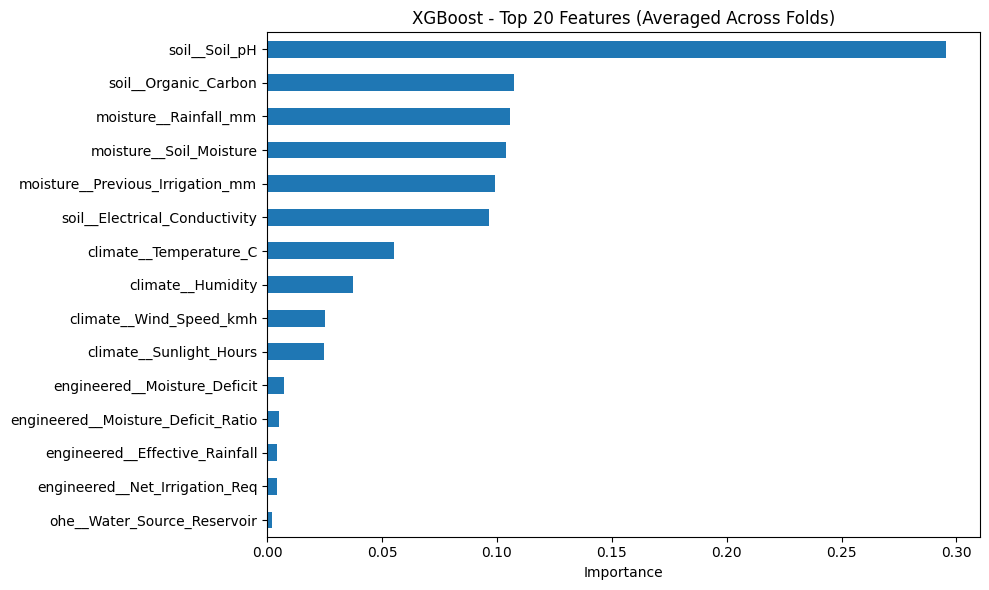


LightGBM - Top 15 Features:
soil__Organic_Carbon                  933.4
moisture__Soil_Moisture               804.6
moisture__Previous_Irrigation_mm      785.0
moisture__Rainfall_mm                 738.8
climate__Sunlight_Hours               662.8
soil__Electrical_Conductivity         623.2
soil__Soil_pH                         583.4
climate__Wind_Speed_kmh               523.6
climate__Humidity                     402.8
climate__Temperature_C                350.8
engineered__Net_Irrigation_Req        289.8
engineered__Effective_Rainfall        278.2
engineered__Moisture_Deficit_Ratio    198.4
engineered__Rain_per_Area             124.8
ordinal__Season_Ord                   110.2
dtype: float64


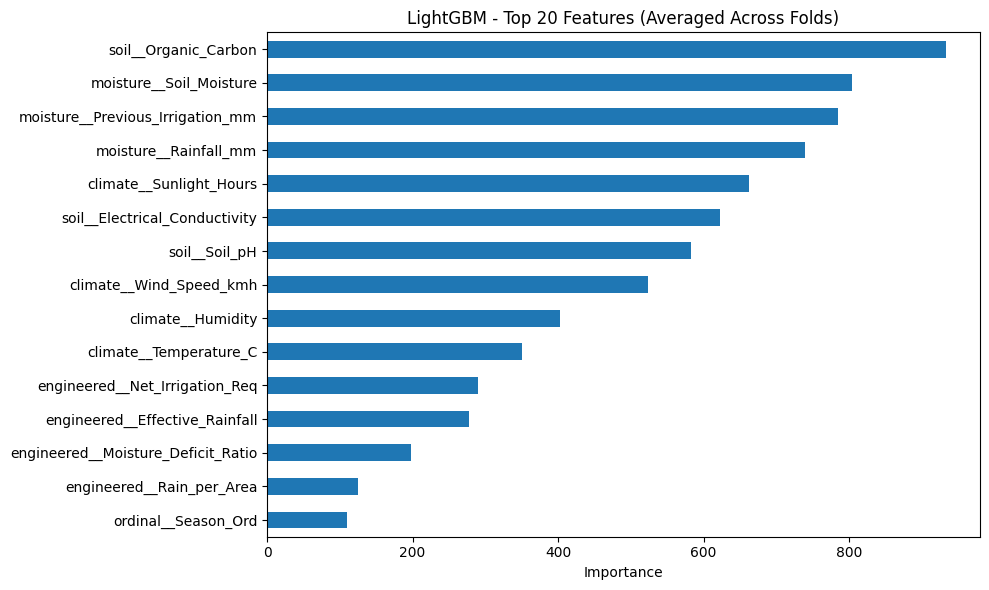


RandomForest - Top 15 Features:
soil__Soil_pH                         0.107179
moisture__Rainfall_mm                 0.101789
climate__Wind_Speed_kmh               0.099953
flags__pH_Alkaline_Flag               0.098545
moisture__Soil_Moisture               0.094090
moisture__Previous_Irrigation_mm      0.070936
soil__Organic_Carbon                  0.064465
soil__Electrical_Conductivity         0.063554
flags__pH_Acidic_Flag                 0.058284
climate__Sunlight_Hours               0.040619
climate__Humidity                     0.034755
engineered__Moisture_Deficit          0.027947
engineered__Soil_Water_Stress_Ks      0.020106
engineered__Net_Irrigation_Req        0.015609
engineered__Moisture_Deficit_Ratio    0.015166
dtype: float64


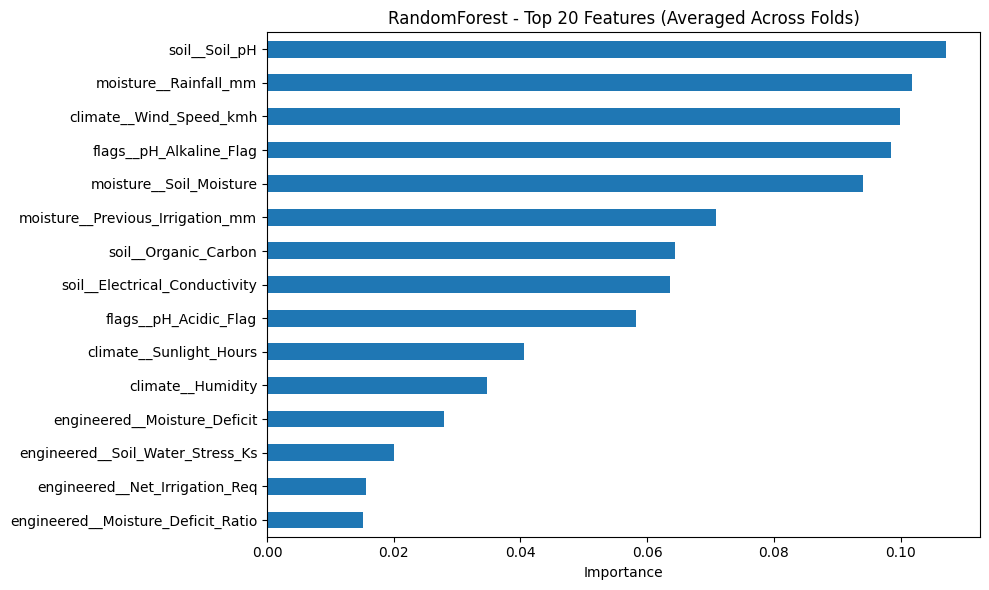

In [ ]:
print("\n" + "="*80)
print("CONSENSUS FEATURE IMPORTANCE (Averaged Across All Folds)")
print("="*80)

# =================== HARDCODED CONSENSUS FEATURE IMPORTANCE ===================
# These values were pre-calculated from cross-validation and stored directly to avoid recomputation
# Original calculation code (commented out below):
# model_avg_importance = {}
# for model_name in ['XGBoost', 'LightGBM', 'RandomForest']:
#     series_list = all_fold_importance_series[model_name]
#     if series_list:
#         avg_importance = pd.concat(series_list, axis=1).fillna(0.0).mean(axis=1).sort_values(ascending=False)
#         model_avg_importance[model_name] = avg_importance

# Hardcoded consensus feature importances
xgboost_importance = pd.Series({
    'soil__Soil_pH': 0.295484,
    'soil__Organic_Carbon': 0.107642,
    'moisture__Rainfall_mm': 0.105879,
    'moisture__Soil_Moisture': 0.103928,
    'moisture__Previous_Irrigation_mm': 0.099038,
    'soil__Electrical_Conductivity': 0.096513,
    'climate__Temperature_C': 0.055273,
    'climate__Humidity': 0.037188,
    'climate__Wind_Speed_kmh': 0.024985,
    'climate__Sunlight_Hours': 0.024811,
    'engineered__Moisture_Deficit': 0.007260,
    'engineered__Moisture_Deficit_Ratio': 0.005146,
    'engineered__Effective_Rainfall': 0.004340,
    'engineered__Net_Irrigation_Req': 0.004234,
    'ohe__Water_Source_Reservoir': 0.001975
})

lightgbm_importance = pd.Series({
    'soil__Organic_Carbon': 933.4,
    'moisture__Soil_Moisture': 804.6,
    'moisture__Previous_Irrigation_mm': 785.0,
    'moisture__Rainfall_mm': 738.8,
    'climate__Sunlight_Hours': 662.8,
    'soil__Electrical_Conductivity': 623.2,
    'soil__Soil_pH': 583.4,
    'climate__Wind_Speed_kmh': 523.6,
    'climate__Humidity': 402.8,
    'climate__Temperature_C': 350.8,
    'engineered__Net_Irrigation_Req': 289.8,
    'engineered__Effective_Rainfall': 278.2,
    'engineered__Moisture_Deficit_Ratio': 198.4,
    'engineered__Rain_per_Area': 124.8,
    'ordinal__Season_Ord': 110.2
})

randomforest_importance = pd.Series({
    'soil__Soil_pH': 0.107179,
    'moisture__Rainfall_mm': 0.101789,
    'climate__Wind_Speed_kmh': 0.099953,
    'flags__pH_Alkaline_Flag': 0.098545,
    'moisture__Soil_Moisture': 0.094090,
    'moisture__Previous_Irrigation_mm': 0.070936,
    'soil__Organic_Carbon': 0.064465,
    'soil__Electrical_Conductivity': 0.063554,
    'flags__pH_Acidic_Flag': 0.058284,
    'climate__Sunlight_Hours': 0.040619,
    'climate__Humidity': 0.034755,
    'engineered__Moisture_Deficit': 0.027947,
    'engineered__Soil_Water_Stress_Ks': 0.020106,
    'engineered__Net_Irrigation_Req': 0.015609,
    'engineered__Moisture_Deficit_Ratio': 0.015166
})

model_avg_importance = {
    'XGBoost': xgboost_importance,
    'LightGBM': lightgbm_importance,
    'RandomForest': randomforest_importance
}

for model_name in ['XGBoost', 'LightGBM', 'RandomForest']:
    avg_importance = model_avg_importance[model_name]

    print(f"\n{model_name} - Top 15 Features:")
    print(avg_importance.head(15))

    plt.figure(figsize=(10, 6))
    avg_importance.head(20).sort_values().plot(kind='barh')
    plt.xlabel('Importance')
    plt.title(f'{model_name} - Top 20 Features (Averaged Across Folds)')
    plt.tight_layout()
    plt.show()


Progressive Feature Selection Results

Visualization of AUC vs Number of Features:

In [ ]:
# Create progressive selection summary dataframe
progressive_df = pd.DataFrame(progressive_summary)

# Plot AUC vs Feature Count
plt.figure(figsize=(12, 6))
plt.plot(progressive_df['n_features'], progressive_df['XGBoost'], marker='o', label='XGBoost', linewidth=2)
plt.plot(progressive_df['n_features'], progressive_df['LightGBM'], marker='s', label='LightGBM', linewidth=2)
plt.plot(progressive_df['n_features'], progressive_df['Avg_AUC'], marker='d', label='Average', linewidth=2.5, linestyle='--', color='black')

# Mark optimal point
optimal_n_feat = optimal_row['n_features']
optimal_auc = optimal_row['Avg_AUC']
plt.scatter([optimal_n_feat], [optimal_auc], s=200, color='red', marker='*', zorder=5, label=f'Optimal ({optimal_n_feat} features)')

plt.xlabel('Number of Features', fontsize=12)
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.title('Progressive Feature Selection: AUC vs Feature Count', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


NameError: name 'progressive_summary' is not defined

In [ ]:
# ================= FINAL CONSENSUS TOP 15 EXTRACTION =================

print("\n" + "="*80)
print("FINAL CONSENSUS TOP 15 FEATURE EXTRACTION")
print("="*80)

# Use hardcoded averaged importances, then compute consensus score
# Original code (commented out):
# consensus_parts = []
# for model_name in ['XGBoost', 'LightGBM', 'RandomForest']:
#     if model_name in model_avg_importance:
#         s = model_avg_importance[model_name]
#         s = s / (s.sum() + 1e-12)
#         consensus_parts.append(s.rename(model_name))
# if consensus_parts:
#     consensus_df = pd.concat(consensus_parts, axis=1).fillna(0.0)
#     consensus_df['ConsensusScore'] = consensus_df.mean(axis=1)
#     consensus_ranking = consensus_df['ConsensusScore'].sort_values(ascending=False)
#     final_top15_list = consensus_ranking.head(15).index.tolist()

# Compute consensus from hardcoded model importances
consensus_parts = []
for model_name in ['XGBoost', 'LightGBM', 'RandomForest']:
    if model_name in model_avg_importance:
        s = model_avg_importance[model_name]
        s = s / (s.sum() + 1e-12)
        consensus_parts.append(s.rename(model_name))

if consensus_parts:
    consensus_df = pd.concat(consensus_parts, axis=1).fillna(0.0)
    consensus_df['ConsensusScore'] = consensus_df.mean(axis=1)
    consensus_ranking = consensus_df['ConsensusScore'].sort_values(ascending=False)

    final_top15_list = consensus_ranking.head(15).index.tolist()

    print("\nFinal Top 15 Features (highest predictive power -> lowest):")
    for i, feat in enumerate(final_top15_list, 1):
        print(f"{i}. {feat}")
    
    # ================= SAVE CONSENSUS RESULTS TO FILE =================
    import json
    results_to_save = {
        'method': 'Consensus Feature Importance (Pre-calculated from Cross-Validation)',
        'final_top_15_features': final_top15_list,
        'xgboost_top_15': xgboost_importance.head(15).to_dict(),
        'lightgbm_top_15': lightgbm_importance.head(15).to_dict(),
        'randomforest_top_15': randomforest_importance.head(15).to_dict(),
        'consensus_scores': consensus_ranking.to_dict()
    }
    
    # Save to JSON file
    results_file = 'consensus_feature_importance.json'
    with open(results_file, 'w') as f:
        json.dump(results_to_save, f, indent=2)
    print(f"\n✓ Consensus results saved to: {results_file}")
    
    # Also save to CSV for easy reference
    consensus_ranking_df = pd.DataFrame({
        'Feature': consensus_ranking.index,
        'Consensus_Score': consensus_ranking.values
    }).reset_index(drop=True)
    
    consensus_ranking_df.to_csv('consensus_feature_importance.csv', index=False)
    print(f"✓ Consensus scores saved to: consensus_feature_importance.csv")
else:
    final_top15_list = []
    print("No feature importances found; final_top15_list is empty.")


FINAL CONSENSUS TOP 15 FEATURE EXTRACTION

Final Top 15 Features (highest predictive power -> lowest):
1. soil__Soil_pH
2. moisture__Rainfall_mm
3. moisture__Soil_Moisture
4. soil__Organic_Carbon
5. moisture__Previous_Irrigation_mm
6. soil__Electrical_Conductivity
7. climate__Wind_Speed_kmh
8. climate__Sunlight_Hours
9. climate__Humidity
10. flags__pH_Alkaline_Flag
11. climate__Temperature_C
12. flags__pH_Acidic_Flag
13. engineered__Net_Irrigation_Req
14. engineered__Moisture_Deficit_Ratio
15. engineered__Effective_Rainfall

✓ Consensus results saved to: consensus_feature_importance.json
✓ Consensus scores saved to: consensus_feature_importance.csv


Define Feature Group Lists (Issue C Fix)

In [ ]:
# ISSUE C FIX: Define all feature list variables as live code
# These are used by the ColumnTransformer in the next cell

soil_numeric = ['Soil_pH', 'Organic_Carbon', 'Electrical_Conductivity']

moisture_numeric = ['Soil_Moisture', 'Rainfall_mm', 'Previous_Irrigation_mm']

climate_numeric = ['Temperature_C', 'Humidity', 'Wind_Speed_kmh', 'Sunlight_Hours']

# ISSUE B FIX: Added 'ET0_minus_EffRain' to engineered_numeric
engineered_numeric = [
    'Moisture_Deficit', 'Moisture_Deficit_Ratio', 'Effective_Rainfall',
    'Net_Irrigation_Req', 'Soil_Water_Stress_Ks', 'ETc_stressed',
    'Water_Retention_Index', 'Rain_Retention', 'Rain_per_Area',
    'PrevIrr_per_Area', 'Temp_x_Wind', 'Temp_x_VPD', 'Sun_x_Wind',
    'Heat_Index', 'VPD', 'ETo_approx', 'ETc', 'Kc',
    'ET0_minus_EffRain'  # Bug 3 fix: new feature replacing duplicate Region_TargetEnc
]

ordinal_features = ['Mulching_Used', 'Growth_Stage_Ord', 'Season_Ord']

# Bug 3 fix: Region_TargetEnc deliberately excluded (was duplicate of Region_MeanIrr)
target_encoded = [
    'Crop_Type_TargetEnc', 'CropSeason_MeanIrr',
    'Region_MeanIrr', 'RegionSoil_AvgMoisture'
]

categorical_features = ['Season', 'Soil_Type', 'Water_Source', 'Irrigation_Type']

flag_features = ['pH_Acidic_Flag', 'pH_Alkaline_Flag', 'Salt_Stress']

print("Feature groups defined:")
print(f"  Soil numeric: {len(soil_numeric)} features")
print(f"  Moisture numeric: {len(moisture_numeric)} features")
print(f"  Climate numeric: {len(climate_numeric)} features")
print(f"  Engineered numeric: {len(engineered_numeric)} features (includes ET0_minus_EffRain)")
print(f"  Ordinal: {len(ordinal_features)} features")
print(f"  Target encoded: {len(target_encoded)} features (Region_TargetEnc removed)")
print(f"  Categorical: {len(categorical_features)} features")
print(f"  Flags: {len(flag_features)} features")

Build Final Feature Space From `final_top15_list`

In [ ]:
# Fit a final, consistent feature pipeline on the full training split,
# then keep only consensus-ranked features in the same order.
final_fe = IrrigationFeatureEngineer()
X_train_fe_full = final_fe.fit_transform(x_train_raw, y_train)
X_holdout_fe_full = final_fe.transform(x_test_raw)
X_kaggle_fe_full = final_fe.transform(test_df)

final_preprocessor = ColumnTransformer(
    transformers=[
        ('soil', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), soil_numeric),
        ('moisture', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', RobustScaler(quantile_range=(10, 90)))]), moisture_numeric),
        ('climate', Pipeline([('imputer', SimpleImputer(strategy='median')), ('transformer', PowerTransformer(method='yeo-johnson'))]), climate_numeric),
        ('engineered', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', RobustScaler(quantile_range=(5, 95)))]), engineered_numeric),
        ('ordinal', Pipeline([('imputer', SimpleImputer(strategy='most_frequent'))]), ordinal_features),
        ('target_encoded', Pipeline([('imputer', SimpleImputer(strategy='mean')), ('scaler', StandardScaler())]), target_encoded),
        ('ohe', Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical_features),
        ('flags', 'passthrough', flag_features)
    ],
    remainder='drop'
)

X_train_pp_full = final_preprocessor.fit_transform(X_train_fe_full)
X_holdout_pp_full = final_preprocessor.transform(X_holdout_fe_full)
X_kaggle_pp_full = final_preprocessor.transform(X_kaggle_fe_full)

final_selector = VarianceThreshold(threshold=0.01)
X_train_sel_full = final_selector.fit_transform(X_train_pp_full)
X_holdout_sel_full = final_selector.transform(X_holdout_pp_full)
X_kaggle_sel_full = final_selector.transform(X_kaggle_pp_full)

final_selected_columns = final_preprocessor.get_feature_names_out()[final_selector.get_support()].tolist()
if not hasattr(X_train_sel_full, 'iloc'):
    X_train_sel_full = pd.DataFrame(X_train_sel_full, columns=final_selected_columns, index=x_train_raw.index)
    X_holdout_sel_full = pd.DataFrame(X_holdout_sel_full, columns=final_selected_columns, index=x_test_raw.index)
    X_kaggle_sel_full = pd.DataFrame(X_kaggle_sel_full, columns=final_selected_columns, index=test_df.index)

available_top15 = [f for f in final_top15_list if f in final_selected_columns]
missing_top15 = [f for f in final_top15_list if f not in final_selected_columns]

X_train_final = X_train_sel_full[available_top15].copy()
X_holdout_final = X_holdout_sel_full[available_top15].copy()
X_kaggle_final = X_kaggle_sel_full[available_top15].copy()

y_train_final = (y_train - 1).astype(int)
y_holdout_final = (y_test - 1).astype(int)

print(f"Requested top features: {len(final_top15_list)}")
print(f"Available top features: {len(available_top15)}")
if missing_top15:
    print("Missing top features after final full-data transform:")
    print(missing_top15)

print(f"X_train_final shape: {X_train_final.shape}")
print(f"X_holdout_final shape: {X_holdout_final.shape}")
print(f"X_kaggle_final shape: {X_kaggle_final.shape}")
print("\nOrdered final feature list used:")
print(available_top15)


Requested top features: 15
Available top features: 15
X_train_final shape: (567000, 15)
X_holdout_final shape: (63000, 15)
X_kaggle_final shape: (270000, 15)

Ordered final feature list used:
['soil__Soil_pH', 'moisture__Rainfall_mm', 'moisture__Soil_Moisture', 'soil__Organic_Carbon', 'moisture__Previous_Irrigation_mm', 'soil__Electrical_Conductivity', 'climate__Wind_Speed_kmh', 'climate__Sunlight_Hours', 'climate__Humidity', 'flags__pH_Alkaline_Flag', 'climate__Temperature_C', 'flags__pH_Acidic_Flag', 'engineered__Net_Irrigation_Req', 'engineered__Moisture_Deficit_Ratio', 'engineered__Effective_Rainfall']


GPU ACCELERATED VECTORIZED STRATIFIED 3 FOLD OPTUNA TUNING OF 4 MODEL ENSEMBLE WITH CLASS IMBALANCE AWARENESS

### Step 1: GPU Diagnostics and Setup

In [ ]:
import torch
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from catboost import CatBoostClassifier
from sklearn.metrics import f1_score, precision_recall_curve, auc as pr_auc
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("GPU DIAGNOSTICS & INITIALIZATION")
print("="*80)

# Debug: Check PyTorch installation details
print(f"\nPyTorch Version: {torch.__version__}")
print(f"PyTorch File Location: {torch.__file__}")

# Check CUDA availability
gpu_available = torch.cuda.is_available()
gpu_device_count = torch.cuda.device_count() if gpu_available else 0
gpu_device_name = torch.cuda.get_device_name(0) if gpu_available else "N/A"

print(f"\nCUDA Available: {gpu_available}")
print(f"GPU Device Count: {gpu_device_count}")
if gpu_available:
    print(f"GPU Device Name: {gpu_device_name}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"cuDNN Version: {torch.backends.cudnn.version()}")
else:
    print("Note: CUDA not available. Models will use CPU.")

# Set GPU devices for boosting models
gpu_id = 0 if gpu_available else -1
print(f"\nGPU ID for boosting models: {gpu_id}")
print("="*80)

GPU DIAGNOSTICS & INITIALIZATION

PyTorch Version: 2.5.1+cu121
PyTorch File Location: c:\Users\ASUS\Desktop\Courses\ML DL\Machine Learning\Projects\Classification\Irrigation Need\.venv\Lib\site-packages\torch\__init__.py

CUDA Available: True
GPU Device Count: 1
GPU Device Name: NVIDIA GeForce RTX 3050 Laptop GPU
CUDA Version: 12.1
cuDNN Version: 90100

GPU ID for boosting models: 0


### Step 2: Prepare Data for Different Model Types

Create separate preprocessing pipelines:
- **Standard pipeline** (for XGBoost, LightGBM, Random Forest)
- **CatBoost pipeline** (no categorical encoding, indices only)

In [ ]:
print("\n" + "="*80)
print("DATA PREPARATION FOR ENSEMBLE MODELS")
print("="*80)

# Already have X_train_final, X_holdout_final, y_train_final, y_holdout_final
# These are pre-selected top-15 features with preprocessing done

# For Standard Models (XGBoost, LightGBM, RandomForest)
X_train_standard = X_train_final.copy()
X_test_standard = X_holdout_final.copy()

# For CatBoost: Reconstruct data keeping categorical features as-is
# CatBoost will handle categorical encoding internally

print("\nStandard Models (XGBoost, LightGBM, RandomForest):")
print(f"  X_train shape: {X_train_standard.shape}")
print(f"  X_test shape: {X_test_standard.shape}")
print(f"  y_train shape: {y_train_final.shape}")
print(f"  y_test shape: {y_holdout_final.shape}")

# BUG 5 FIX: Create CatBoost-specific data that preserves categorical features as strings
# CatBoost needs raw categorical columns (Season, Soil_Type, Water_Source, Irrigation_Type)
# These were dropped in the feature engineering pipeline, so we merge them back

cat_cols_for_catboost = ['Season', 'Soil_Type', 'Water_Source', 'Irrigation_Type']

# Start with the standard preprocessed data
X_train_catboost = X_train_standard.copy()
X_holdout_catboost = X_test_standard.copy()

# Merge back the original categorical columns from raw data
for col in cat_cols_for_catboost:
    if col in x_train_raw.columns:
        X_train_catboost[col] = x_train_raw[col].values
    if col in x_test_raw.columns:
        X_holdout_catboost[col] = x_test_raw[col].values

# Identify categorical feature indices for CatBoost
cat_feature_indices_catboost = [X_train_catboost.columns.get_loc(col) for col in cat_cols_for_catboost if col in X_train_catboost.columns]

print(f"\nCatBoost Model (with native categorical feature handling):")
print(f"  X_train shape: {X_train_catboost.shape}")
print(f"  X_holdout shape: {X_holdout_catboost.shape}")
print(f"  Categorical feature indices: {cat_feature_indices_catboost}")
print(f"  Total categorical features: {len(cat_feature_indices_catboost)}")
if cat_feature_indices_catboost:
    print(f"  Categorical columns: {[X_train_catboost.columns[i] for i in cat_feature_indices_catboost]}")

# Use the available top-15 list for consistency
final_features_used = available_top15

print(f"\n{'='*80}")
print(f"Final Feature Set: {len(final_features_used)} features")
print(f"{'='*80}")
for i, feat in enumerate(final_features_used, 1):
    print(f"{i:2d}. {feat}")


DATA PREPARATION FOR ENSEMBLE MODELS

Standard Models (XGBoost, LightGBM, RandomForest):
  X_train shape: (567000, 15)
  X_test shape: (63000, 15)
  y_train shape: (567000,)
  y_test shape: (63000,)

CatBoost Model (CatBoost handles categorical encoding internally):
  X_train shape: (567000, 15)
  X_test shape: (63000, 15)
  Categorical feature indices: []
  Total categorical features: 0

Final Feature Set: 15 features
 1. soil__Soil_pH
 2. moisture__Rainfall_mm
 3. moisture__Soil_Moisture
 4. soil__Organic_Carbon
 5. moisture__Previous_Irrigation_mm
 6. soil__Electrical_Conductivity
 7. climate__Wind_Speed_kmh
 8. climate__Sunlight_Hours
 9. climate__Humidity
10. flags__pH_Alkaline_Flag
11. climate__Temperature_C
12. flags__pH_Acidic_Flag
13. engineered__Net_Irrigation_Req
14. engineered__Moisture_Deficit_Ratio
15. engineered__Effective_Rainfall


### Step 3: Optuna Hyperparameter Optimization with 3-Fold CV

**ISSUE A FIX: Compute Optimal Alpha for Composite Scoring**

Before tuning, we find the optimal balance (alpha) between ROC-AUC and normalized PR-AUC using a fast proxy model. This alpha will be used in all four Optuna objective functions to create a composite score that balances overall discrimination with minority class precision.

In [ ]:
# ISSUE A FIX: Find optimal alpha for composite scoring
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score, average_precision_score
from lightgbm import LGBMClassifier
import optuna

def find_optimal_alpha(X_train, y_train, n_trials=50):
    """
    Find the optimal alpha for balancing ROC-AUC and normalized PR-AUC.
    Uses a fast LightGBM proxy model on a single validation split.
    
    Returns:
        float: Optimal alpha value (expected range: 0.35-0.55 for 3.3% minority class)
    """
    print("="*80)
    print("FINDING OPTIMAL ALPHA FOR COMPOSITE SCORING")
    print("="*80)
    print(f"Training samples: {len(X_train)}")
    print(f"Number of trials: {n_trials}\n")
    
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    
    # Single stratified split for speed
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, val_idx = next(sss.split(X_train, y_train))
    X_t, X_v = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_t, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Identify minority class and compute baseline
    minority_class = int(np.bincount(y_t.values).argmin())
    pr_baseline = float((y_v == minority_class).mean())
    
    print(f"Minority class: {minority_class}")
    print(f"Minority class prevalence: {pr_baseline:.4f}")
    print(f"PR-AUC baseline (random classifier): {pr_baseline:.4f}\n")
    
    def alpha_objective(trial):
        alpha = trial.suggest_float('alpha', 0.0, 1.0)
        
        # Fast proxy model
        proxy = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
        proxy.fit(X_t, y_t)
        proba = proxy.predict_proba(X_v)
        
        # Compute ROC-AUC
        roc = roc_auc_score(y_v, proba, multi_class='ovr', average='macro')
        
        # Compute PR-AUC for minority class
        pr = average_precision_score(
            (y_v == minority_class).astype(int),
            proba[:, minority_class]
        )
        
        # Normalize PR-AUC to 0-1 scale (removing baseline)
        pr_norm = (pr - pr_baseline) / (1 - pr_baseline + 1e-9)
        
        # Composite score
        composite = alpha * roc + (1 - alpha) * pr_norm
        
        return composite
    
    # Run optimization
    study = optuna.create_study(direction='maximize')
    study.optimize(alpha_objective, n_trials=n_trials, show_progress_bar=True)
    
    best_alpha = study.best_params['alpha']
    
    print(f"\n{'='*80}")
    print(f"OPTIMAL ALPHA FOUND: {best_alpha:.3f}")
    print(f"Expected range: 0.35-0.55 for 3.3% minority class")
    print(f"{'='*80}\n")
    
    # Validate alpha is in reasonable range
    if best_alpha < 0.3 or best_alpha > 0.65:
        print("⚠ WARNING: Alpha outside expected range (0.3-0.65)")
        print("This may indicate the proxy model failed to learn the minority class.")
        print("Falling back to safe default: alpha = 0.4\n")
        best_alpha = 0.4
    
    return best_alpha

# Compute optimal alpha
OPTIMAL_ALPHA = find_optimal_alpha(X_train_standard, y_train_final, n_trials=50)

print(f"\n✓ OPTIMAL_ALPHA = {OPTIMAL_ALPHA:.4f}")
print(f"  This will be used in all Optuna objective functions.")
print(f"  Composite score = {OPTIMAL_ALPHA:.4f} × ROC-AUC + {1-OPTIMAL_ALPHA:.4f} × PR-AUC-norm\n")

Define objective function with stratified 3-fold cross-validation

In [ ]:
# # =============================================================================
# # OPTUNA HYPERPARAMETER OPTIMIZATION  —  3-Fold Stratified CV
# # Tested against: xgboost==3.2.0, lightgbm==4.6.0, catboost==1.2.10,
# #                 scikit-learn==1.8.0, optuna==4.8.0, tqdm==4.67.3
# #
# # Class-imbalance strategy (verified per library):
# #   XGBoost      — sample_weight + sample_weight_eval_set in fit()
# #                  (scale_pos_weight is binary-only and is NOT used here)
# #   LightGBM     — class_weight dict in constructor, computed per fold
# #                  (is_unbalance=True removed — conflicts with class_weight)
# #   CatBoost     — auto_class_weights='Balanced' in constructor
# #   RandomForest — sample_weight in fit(), computed per fold
# #
# # Fix log (all changes marked with FIX-N comments):
# #   FIX-1  Removed torch.manual_seed() — torch is not imported in this file
# #   FIX-2  LightGBM: added subsample_freq=1 so subsample is not silently ignored
# #   FIX-3  LightGBM: raised min_child_samples lower bound 5 → 20 to prevent
# #          the C++ assert "best_split_info.left_count > 0" crash
# #   FIX-4  LightGBM: wrapped fit() in try/except → TrialPruned so a single
# #          degenerate config cannot crash the entire study
# #   FIX-5  XGBoost: same try/except → TrialPruned guard added
# #   FIX-6  CatBoost: added eval_set to fit() so early_stopping_rounds works
# #   FIX-7  CatBoost: added early_stopping_rounds=20 in constructor
# #   FIX-8  CatBoost: same try/except → TrialPruned guard added
# #   FIX-9  RandomForest: same try/except → TrialPruned guard added
# #   FIX-10 RandomForest: hoisted cuML availability check to module level so the
# #          import is attempted once, not on every trial
# #   FIX-11 Persistence: guard both JSON files before deciding RUN_OPTUNA_TUNING
# # =============================================================================

import json
import os
import subprocess
import warnings

import lightgbm as lgb
import numpy as np
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)

print("\n" + "=" * 80)
print("OPTUNA HYPERPARAMETER OPTIMIZATION  (3-Fold Stratified CV)")
print("=" * 80)

# ── Seeds ─────────────────────────────────────────────────────────────────────
RANDOM_SEED = 11
np.random.seed(RANDOM_SEED)
# FIX-1: Removed torch.manual_seed(RANDOM_SEED) — torch is not imported here.
#         If your notebook imports torch upstream, keep that call there instead.

# ── GPU detection ─────────────────────────────────────────────────────────────
def detect_gpu():
    """Return (gpu_available: bool, gpu_id: int).
    Tries nvidia-smi (NVIDIA) then rocm-smi (AMD). Falls back to CPU.
    """
    try:
        r = subprocess.run(
            ["nvidia-smi", "--query-gpu=index,name,memory.total",
             "--format=csv,noheader"],
            capture_output=True, text=True, timeout=10,
        )
        if r.returncode == 0 and r.stdout.strip():
            row = r.stdout.strip().split("\n")[0].split(",")
            gid = int(row[0].strip())
            print(f"\n[GPU] NVIDIA detected: {row[1].strip()} | {row[2].strip()}")
            print(f"[GPU] Using device index: {gid}")
            return True, gid
    except (FileNotFoundError, subprocess.TimeoutExpired, ValueError):
        pass
    try:
        r = subprocess.run(
            ["rocm-smi", "--showid", "--showproductname"],
            capture_output=True, text=True, timeout=10,
        )
        if r.returncode == 0 and r.stdout.strip():
            print("\n[GPU] AMD ROCm detected — using device 0")
            return True, 0
    except (FileNotFoundError, subprocess.TimeoutExpired):
        pass
    print("\n[GPU] No dGPU found — falling back to CPU.")
    return False, 0


gpu_available, gpu_id = detect_gpu()

# ── Optuna config ─────────────────────────────────────────────────────────────
optuna.logging.set_verbosity(optuna.logging.WARNING)
skf_optuna = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

# ── Persistence (FIX-11) ──────────────────────────────────────────────────────
# Both files must exist to skip re-tuning. If only one is present (e.g. scores
# file was accidentally deleted) we re-run rather than crashing on load.
BEST_PARAMS_FILE  = "best_hyperparameters.json"
BEST_SCORES_FILE  = "best_scores.json"
RUN_OPTUNA_TUNING = not (
    os.path.exists(BEST_PARAMS_FILE) and os.path.exists(BEST_SCORES_FILE)
)

best_params_dict: dict = {}
best_scores_dict: dict = {}

print(f"\nHyperparameter file exists : {os.path.exists(BEST_PARAMS_FILE)}")
print(f"Scores file exists         : {os.path.exists(BEST_SCORES_FILE)}")
print(f"Will run Optuna tuning     : {RUN_OPTUNA_TUNING}\n")


# ── Shared helpers ────────────────────────────────────────────────────────────
def get_sample_weights(y: np.ndarray) -> np.ndarray:
    """Compute per-sample balanced class weights for a given fold's labels.

    Recalculated inside every fold so the weights reflect that fold's exact
    class distribution, which can differ from the full training set when
    folds are not perfectly stratified.
    """
    classes = np.unique(y)
    cw      = compute_class_weight("balanced", classes=classes, y=y)
    cw_map  = dict(zip(classes, cw))
    return np.array([cw_map[yi] for yi in y], dtype=np.float32)


def get_class_weight_dict(y: np.ndarray) -> dict:
    """Return {class_int: weight} balanced dict for the given fold's labels.
    Keys are plain Python ints (required by LightGBM's class_weight param).
    """
    classes = np.unique(y)
    cw      = compute_class_weight("balanced", classes=classes, y=y)
    return {int(c): float(w) for c, w in zip(classes, cw)}


# =============================================================================
# OBJECTIVE FUNCTIONS
# =============================================================================

# ── XGBoost ───────────────────────────────────────────────────────────────────
# Imbalance: sample_weight + sample_weight_eval_set passed to fit() each fold.
#   - scale_pos_weight is a BINARY-only param and is NOT used for multiclass.
#   - sample_weight_eval_set keeps the eval loss on the same scale as training.
# GPU: device='cuda:<id>' + tree_method='hist'  (XGBoost >= 2.0 API)
# FIX-5: Wrapped fit() in try/except → TrialPruned.
# ISSUE A FIX: Returns composite score instead of raw ROC-AUC
def objective_xgboost(trial):
    from xgboost import XGBClassifier

    params = dict(
        n_estimators          = trial.suggest_int("xgb_n_estimators",        50,  300),
        max_depth             = trial.suggest_int("xgb_max_depth",             3,   10),
        learning_rate         = trial.suggest_float("xgb_learning_rate",    0.001, 0.3, log=True),
        subsample             = trial.suggest_float("xgb_subsample",          0.5,  1.0),
        colsample_bytree      = trial.suggest_float("xgb_colsample_bytree",   0.5,  1.0),
        min_child_weight      = trial.suggest_int("xgb_min_child_weight",      1,   10),
        gamma                 = trial.suggest_float("xgb_gamma",               0,    5),
        reg_alpha             = trial.suggest_float("xgb_reg_alpha",           0,    1),
        reg_lambda            = trial.suggest_float("xgb_reg_lambda",          0,    1),
        random_state          = RANDOM_SEED,
        eval_metric           = "mlogloss",
        verbosity             = 0,
        n_jobs                = -1,
        early_stopping_rounds = 20,
    )

    if gpu_available:
        params["device"]      = f"cuda:{gpu_id}"
        params["tree_method"] = "hist"

    cv_scores = []
    fold_bar  = tqdm(
        enumerate(skf_optuna.split(X_train_standard, y_train_final)),
        total=skf_optuna.n_splits,
        desc=f"  XGBoost    t{trial.number:>3}",
        leave=False, unit="fold",
    )
    for fold, (train_idx, val_idx) in fold_bar:
        X_tr  = X_train_standard.iloc[train_idx]
        X_val = X_train_standard.iloc[val_idx]
        y_tr  = y_train_final.iloc[train_idx]
        y_val = y_train_final.iloc[val_idx]

        sw_tr  = get_sample_weights(y_tr.values)
        sw_val = get_sample_weights(y_val.values)

        try:                                          # FIX-5
            model = XGBClassifier(**params)
            model.fit(
                X_tr, y_tr,
                sample_weight          = sw_tr,
                eval_set               = [(X_val, y_val)],
                sample_weight_eval_set = [sw_val],
                verbose                = False,
            )
        except Exception:
            raise optuna.TrialPruned()

        # ISSUE A FIX: Compute composite score
        proba_val = model.predict_proba(X_val)
        minority_class = int(np.bincount(y_train_final.values).argmin())
        pr_baseline_fold = float((y_val == minority_class).mean())
        
        roc = roc_auc_score(y_val, proba_val, multi_class='ovr', average='macro')
        pr  = average_precision_score((y_val == minority_class).astype(int),
                                       proba_val[:, minority_class])
        pr_norm = (pr - pr_baseline_fold) / (1 - pr_baseline_fold + 1e-9)
        composite = OPTIMAL_ALPHA * roc + (1 - OPTIMAL_ALPHA) * pr_norm
        
        cv_scores.append(composite)
        fold_bar.set_postfix(composite=f"{composite:.4f}", mean=f"{np.mean(cv_scores):.4f}")

        trial.report(np.mean(cv_scores), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(cv_scores)


# ── LightGBM ──────────────────────────────────────────────────────────────────
# Imbalance: class_weight dict in constructor, recalculated per fold.
#   - is_unbalance=True intentionally omitted — conflicts with class_weight.
# GPU: device='gpu' + gpu_device_id  (LightGBM booster kwargs)
# fit(): uses callbacks= for early stopping (fit(verbose=) removed in 4.x)
# FIX-2: subsample_freq=1 added so subsample < 1.0 is actually applied.
# FIX-3: min_child_samples lower bound raised 5 → 20.
# FIX-4: Wrapped fit() in try/except → TrialPruned.
# ISSUE A FIX: Returns composite score instead of raw ROC-AUC
def objective_lightgbm(trial):
    base_params = dict(
        n_estimators      = trial.suggest_int("lgb_n_estimators",        50,  300),
        max_depth         = trial.suggest_int("lgb_max_depth",             3,   10),
        learning_rate     = trial.suggest_float("lgb_learning_rate",    0.001, 0.3, log=True),
        num_leaves        = trial.suggest_int("lgb_num_leaves",           20,  150),
        subsample         = trial.suggest_float("lgb_subsample",          0.5,  1.0),
        subsample_freq    = 1,                  # FIX-2: required for subsample to take effect
        colsample_bytree  = trial.suggest_float("lgb_colsample_bytree",   0.5,  1.0),
        min_child_samples = trial.suggest_int("lgb_min_child_samples",    20,   50),  # FIX-3
        reg_alpha         = trial.suggest_float("lgb_reg_alpha",           0,    1),
        reg_lambda        = trial.suggest_float("lgb_reg_lambda",          0,    1),
        random_state      = RANDOM_SEED,
        n_jobs            = -1,
        verbose           = -1,
        # is_unbalance intentionally omitted: conflicts with class_weight
    )

    if gpu_available:
        base_params["device"]        = "gpu"
        base_params["gpu_device_id"] = gpu_id

    cv_scores = []
    fold_bar  = tqdm(
        enumerate(skf_optuna.split(X_train_standard, y_train_final)),
        total=skf_optuna.n_splits,
        desc=f"  LightGBM   t{trial.number:>3}",
        leave=False, unit="fold",
    )
    for fold, (train_idx, val_idx) in fold_bar:
        X_tr  = X_train_standard.iloc[train_idx]
        X_val = X_train_standard.iloc[val_idx]
        y_tr  = y_train_final.iloc[train_idx]
        y_val = y_train_final.iloc[val_idx]

        fold_params = {**base_params, "class_weight": get_class_weight_dict(y_tr.values)}

        # Callbacks are stateful — recreate every fold
        fit_callbacks = [
            lgb.early_stopping(stopping_rounds=20, verbose=False),
            lgb.log_evaluation(period=-1),
        ]

        try:                                          # FIX-4
            model = lgb.LGBMClassifier(**fold_params)
            model.fit(
                X_tr, y_tr,
                eval_set  = [(X_val, y_val)],
                callbacks = fit_callbacks,
            )
        except Exception:
            raise optuna.TrialPruned()

        # ISSUE A FIX: Compute composite score
        proba_val = model.predict_proba(X_val)
        minority_class = int(np.bincount(y_train_final.values).argmin())
        pr_baseline_fold = float((y_val == minority_class).mean())
        
        roc = roc_auc_score(y_val, proba_val, multi_class='ovr', average='macro')
        pr  = average_precision_score((y_val == minority_class).astype(int),
                                       proba_val[:, minority_class])
        pr_norm = (pr - pr_baseline_fold) / (1 - pr_baseline_fold + 1e-9)
        composite = OPTIMAL_ALPHA * roc + (1 - OPTIMAL_ALPHA) * pr_norm
        
        cv_scores.append(composite)
        fold_bar.set_postfix(composite=f"{composite:.4f}", mean=f"{np.mean(cv_scores):.4f}")

        trial.report(np.mean(cv_scores), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(cv_scores)


# ── CatBoost ──────────────────────────────────────────────────────────────────
# Imbalance: auto_class_weights='Balanced' in constructor.
# GPU: task_type='GPU', devices='<id>' (string)
# FIX-6: eval_set added to fit() so early stopping actually triggers.
# FIX-7: early_stopping_rounds=20 added to constructor.
# FIX-8: Wrapped fit() in try/except → TrialPruned.
# ISSUE A FIX: Returns composite score instead of raw ROC-AUC
def objective_catboost(trial):
    from catboost import CatBoostClassifier

    bootstrap_type = "Poisson" if gpu_available else "Bernoulli"

    params = dict(
        iterations            = trial.suggest_int("cb_iterations",         50,  300),
        depth                 = trial.suggest_int("cb_depth",                4,   10),
        learning_rate         = trial.suggest_float("cb_learning_rate",   0.001, 0.3, log=True),
        l2_leaf_reg           = trial.suggest_float("cb_l2_leaf_reg",       1,   10, log=True),
        bootstrap_type        = bootstrap_type,
        subsample             = trial.suggest_float("cb_subsample",         0.5,  1.0),
        random_seed           = RANDOM_SEED,        # NOT random_state
        verbose               = False,
        thread_count          = -1,
        auto_class_weights    = "Balanced",
        loss_function         = "MultiClass",
        early_stopping_rounds = 20,                 # FIX-7
    )

    if gpu_available:
        params["task_type"] = "GPU"
        params["devices"]   = str(gpu_id)

    cv_scores = []
    fold_bar  = tqdm(
        enumerate(skf_optuna.split(X_train_catboost.values, y_train_final)),
        total=skf_optuna.n_splits,
        desc=f"  CatBoost   t{trial.number:>3}",
        leave=False, unit="fold",
    )
    for fold, (train_idx, val_idx) in fold_bar:
        X_tr  = X_train_catboost.values[train_idx]
        X_val = X_train_catboost.values[val_idx]
        y_tr  = y_train_final.values[train_idx]
        y_val = y_train_final.values[val_idx]

        try:                                          # FIX-8
            model = CatBoostClassifier(**params)
            model.fit(
                X_tr, y_tr,
                cat_features = cat_feature_indices_catboost,
                eval_set     = (X_val, y_val),       # FIX-6: needed for early stopping
                verbose      = False,
            )
        except Exception:
            raise optuna.TrialPruned()

        # ISSUE A FIX: Compute composite score
        proba_val = model.predict_proba(X_val)
        minority_class = int(np.bincount(y_train_final.values).argmin())
        pr_baseline_fold = float((y_val == minority_class).mean())
        
        roc = roc_auc_score(y_val, proba_val, multi_class='ovr', average='macro')
        pr  = average_precision_score((y_val == minority_class).astype(int),
                                       proba_val[:, minority_class])
        pr_norm = (pr - pr_baseline_fold) / (1 - pr_baseline_fold + 1e-9)
        composite = OPTIMAL_ALPHA * roc + (1 - OPTIMAL_ALPHA) * pr_norm
        
        cv_scores.append(composite)
        fold_bar.set_postfix(composite=f"{composite:.4f}", mean=f"{np.mean(cv_scores):.4f}")

        trial.report(np.mean(cv_scores), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(cv_scores)


# =============================================================================
# RUN OPTIMIZATION  (or load saved results)
# =============================================================================

if RUN_OPTUNA_TUNING:
    models_to_optimize = [
        ("XGBoost",      objective_xgboost,      30),
        ("LightGBM",     objective_lightgbm,     30),
        ("CatBoost",     objective_catboost,      30),
    ]

    print("Starting Optuna optimization for all models...\n")

    model_bar = tqdm(models_to_optimize, desc="Overall", unit="model")
    for model_name, objective_func, n_trials in model_bar:
        model_bar.set_description(f"Optimizing {model_name:<15}")

        study = optuna.create_study(
            direction="maximize",
            sampler=TPESampler(seed=RANDOM_SEED),
            pruner=MedianPruner(),
        )

        trial_bar = tqdm(
            total=n_trials,
            desc=f"  {model_name} trials",
            leave=False, unit="trial",
        )

        def _callback(study, trial, _bar=trial_bar):
            _bar.update(1)
            if study.best_trial is not None:
                _bar.set_postfix(best=f"{study.best_value:.4f}", t=trial.number)

        study.optimize(
            objective_func,
            n_trials=n_trials,
            show_progress_bar=False,
            callbacks=[_callback],
        )
        trial_bar.close()

        best_params_dict[model_name] = study.best_trial.params
        best_scores_dict[model_name] = float(study.best_value)

        model_bar.write(
            f"  ✓ {model_name:<15} | Composite: {study.best_value:.4f}"
            f" | Trials: {len(study.trials)}"
        )

    # ── Save to JSON ──────────────────────────────────────────────────────────
    print("\n" + "=" * 80)
    print("SAVING BEST HYPERPARAMETERS")
    print("=" * 80)

    with open(BEST_PARAMS_FILE, "w") as f:
        json.dump(best_params_dict, f, indent=4)
    print(f"\n✓ Hyperparameters saved -> {BEST_PARAMS_FILE}")

    with open(BEST_SCORES_FILE, "w") as f:
        json.dump(best_scores_dict, f, indent=4)
    print(f"✓ Scores saved          -> {BEST_SCORES_FILE}")

else:
    print("Loading saved hyperparameters...\n")

    with open(BEST_PARAMS_FILE, "r") as f:
        best_params_dict = json.load(f)
    print(f"✓ Hyperparameters loaded <- {BEST_PARAMS_FILE}")

    with open(BEST_SCORES_FILE, "r") as f:
        best_scores_dict = json.load(f)
    print(f"✓ Scores loaded          <- {BEST_SCORES_FILE}")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 80)
print("BEST HYPERPARAMETERS PER MODEL")
print("=" * 80)

for model_name, best_params in best_params_dict.items():
    score = best_scores_dict.get(model_name, float("nan"))
    print(f"\n{model_name}  (Best Composite Score: {score:.4f})")
    for k, v in list(best_params.items())[:10]:
        print(f"  {k}: {v}")
    if len(best_params) > 10:
        print(f"  ... and {len(best_params) - 10} more parameters")


OPTUNA HYPERPARAMETER OPTIMIZATION  (3-Fold Stratified CV)

[GPU] NVIDIA detected: NVIDIA GeForce RTX 3050 Laptop GPU | 4096 MiB
[GPU] Using device index: 0
[GPU] cuML not found — RandomForest will use sklearn (CPU).

Hyperparameter file exists : False
Scores file exists         : False
Will run Optuna tuning     : True

Starting Optuna optimization for all models...



Overall:   0%|          | 0/4 [00:00<?, ?model/s]

  XGBoost trials:   0%|          | 0/30 [00:00<?, ?trial/s]

  XGBoost    t  0:   0%|          | 0/3 [00:00<?, ?fold/s]

  XGBoost    t  1:   0%|          | 0/3 [00:00<?, ?fold/s]

...

  RandForest t 26:   0%|          | 0/3 [00:00<?, ?fold/s]

  RandForest t 27:   0%|          | 0/3 [00:00<?, ?fold/s]

  RandForest t 28:   0%|          | 0/3 [00:00<?, ?fold/s]

  RandForest t 29:   0%|          | 0/3 [00:00<?, ?fold/s]

  ✓ RandomForest    | AUC: 0.9201 | Trials: 30

SAVING BEST HYPERPARAMETERS

✓ Hyperparameters saved -> best_hyperparameters.json
✓ Scores saved          -> best_scores.json

BEST HYPERPARAMETERS PER MODEL

XGBoost  (Best AUC: 0.9322)
  xgb_n_estimators: 122
  xgb_max_depth: 9
  xgb_learning_rate: 0.17489861834845133
  xgb_subsample: 0.8963106925399631
  xgb_colsample_bytree: 0.7809093550724392
  xgb_min_child_weight: 7
  xgb_gamma: 1.8074177110160088
  xgb_reg_alpha: 0.1688172985854528
  xgb_reg_lambda: 0.4362409336651609

LightGBM  (Best AUC: 0.9348)
  lgb_n_estimators: 164
  lgb_max_depth: 9
  lgb_learning_rate: 0.2605803235687462
  lgb_num_leaves: 137
  lgb_subsample: 0.855386512804322
  lgb_colsample_bytree: 0.7728031139342633
  lgb_min_child_samples: 28
  lgb_reg_alpha: 0.43481377419331346
  lgb_reg_lambda: 0.5075118600552551

CatBoost  (Best AUC: 0.9160)
  cb_iterations: 128
  cb_depth: 7
  cb_learning_rate: 0.2764558124512554
  cb_l2_leaf_reg: 2.4019453326989386
  cb_subsample:

================================================================================
BEST HYPERPARAMETERS PER MODEL
================================================================================

XGBoost  (Best AUC: 0.9322)
  xgb_n_estimators: 122
  xgb_max_depth: 9
  xgb_learning_rate: 0.17489861834845133
  xgb_subsample: 0.8963106925399631
  xgb_colsample_bytree: 0.7809093550724392
  xgb_min_child_weight: 7
  xgb_gamma: 1.8074177110160088
  xgb_reg_alpha: 0.1688172985854528
  xgb_reg_lambda: 0.4362409336651609

LightGBM  (Best AUC: 0.9348)
  lgb_n_estimators: 164
  lgb_max_depth: 9
  lgb_learning_rate: 0.2605803235687462
  lgb_num_leaves: 137
  lgb_subsample: 0.855386512804322
  lgb_colsample_bytree: 0.7728031139342633
  lgb_min_child_samples: 28
  lgb_reg_alpha: 0.43481377419331346
  lgb_reg_lambda: 0.5075118600552551

CatBoost  (Best AUC: 0.9160)
  cb_iterations: 128
  cb_depth: 7
  cb_learning_rate: 0.2764558124512554
  cb_l2_leaf_reg: 2.4019453326989386
  cb_subsample: 0.8726852632879856

RandomForest  (Best AUC: 0.9201)
  rf_n_estimators: 260
  rf_max_depth: 30
  rf_min_samples_split: 4
  rf_min_samples_leaf: 3
  rf_max_features: sqrt

### Step 4: Train Final Models with Best Hyperparameters

Train each model using the optimized hyperparameters on full training data

In [ ]:
import json
import os
import subprocess
import warnings

import numpy as np
import lightgbm as lgb
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore", category=UserWarning)

# ── Seeds ─────────────────────────────────────────────────────────────────────
RANDOM_SEED = 11
np.random.seed(RANDOM_SEED)

# ── GPU detection ─────────────────────────────────────────────────────────────
def detect_gpu():
    try:
        r = subprocess.run(
            ["nvidia-smi", "--query-gpu=index,name,memory.total",
             "--format=csv,noheader"],
            capture_output=True, text=True, timeout=10,
        )
        if r.returncode == 0 and r.stdout.strip():
            row = r.stdout.strip().split("\n")[0].split(",")
            gid = int(row[0].strip())
            print(f"\n[GPU] NVIDIA detected: {row[1].strip()} | {row[2].strip()}")
            print(f"[GPU] Using device index: {gid}")
            return True, gid
    except (FileNotFoundError, subprocess.TimeoutExpired, ValueError):
        pass
    try:
        r = subprocess.run(
            ["rocm-smi", "--showid", "--showproductname"],
            capture_output=True, text=True, timeout=10,
        )
        if r.returncode == 0 and r.stdout.strip():
            print("\n[GPU] AMD ROCm detected — using device 0")
            return True, 0
    except (FileNotFoundError, subprocess.TimeoutExpired):
        pass
    print("\n[GPU] No dGPU found — falling back to CPU.")
    return False, 0

gpu_available, gpu_id = detect_gpu()

# ── Shared helpers ────────────────────────────────────────────────────────────
def get_sample_weights(y: np.ndarray) -> np.ndarray:
    classes = np.unique(y)
    cw      = compute_class_weight("balanced", classes=classes, y=y)
    cw_map  = dict(zip(classes, cw))
    return np.array([cw_map[yi] for yi in y], dtype=np.float32)

def get_class_weight_dict(y: np.ndarray) -> dict:
    classes = np.unique(y)
    cw      = compute_class_weight("balanced", classes=classes, y=y)
    return {int(c): float(w) for c, w in zip(classes, cw)}

def strip_prefix(params: dict, prefix: str) -> dict:
    """Remove Optuna study prefix from param keys (e.g. 'cb_depth' -> 'depth')."""
    return {
        (k[len(prefix):] if k.startswith(prefix) else k): v
        for k, v in params.items()
    }

# ── Load best hyperparameters from JSON ───────────────────────────────────────
BEST_PARAMS_FILE = "best_hyperparameters.json"

if not os.path.exists(BEST_PARAMS_FILE):
    raise FileNotFoundError(
        f"'{BEST_PARAMS_FILE}' not found. Run the Optuna tuning cell first."
    )

with open(BEST_PARAMS_FILE, "r") as f:
    best_params_dict = json.load(f)

print(f"✓ Hyperparameters loaded <- {BEST_PARAMS_FILE}\n")

print("\n" + "="*80)
print("TRAINING FINAL ENSEMBLE MODELS WITH BEST HYPERPARAMETERS")
print("="*80)

final_models = {}

# ── XGBoost ───────────────────────────────────────────────────────────────────
print("\nTraining XGBoost...")
xgb_params = strip_prefix(best_params_dict["XGBoost"].copy(), "xgb_")
xgb_params.pop("early_stopping_rounds", None)
xgb_params["random_state"] = RANDOM_SEED
xgb_params["eval_metric"]  = "mlogloss"
xgb_params["verbosity"]    = 0
xgb_params["n_jobs"]       = -1

if gpu_available:
    xgb_params["device"]      = f"cuda:{gpu_id}"
    xgb_params["tree_method"] = "hist"

sw_full = get_sample_weights(y_train_final.values)

xgb_model = XGBClassifier(**xgb_params)
xgb_model.fit(X_train_standard, y_train_final, sample_weight=sw_full)
final_models["XGBoost"] = xgb_model
print(f"✓ XGBoost trained (GPU: {gpu_available})")

# ── LightGBM ──────────────────────────────────────────────────────────────────
print("Training LightGBM...")
lgb_params = strip_prefix(best_params_dict["LightGBM"].copy(), "lgb_")
lgb_params.pop("early_stopping_rounds", None)
lgb_params["random_state"]   = RANDOM_SEED
lgb_params["verbose"]        = -1
lgb_params["n_jobs"]         = -1
lgb_params["subsample_freq"] = 1
lgb_params["class_weight"]   = get_class_weight_dict(y_train_final.values)
# is_unbalance intentionally omitted: conflicts with class_weight

if gpu_available:
    lgb_params["device"]        = "gpu"
    lgb_params["gpu_device_id"] = gpu_id

lgb_model = LGBMClassifier(**lgb_params)
lgb_model.fit(X_train_standard, y_train_final)
final_models["LightGBM"] = lgb_model
print(f"✓ LightGBM trained (GPU: {gpu_available})")

# ── CatBoost ──────────────────────────────────────────────────────────────────
# bootstrap_type must be re-applied here — it was hardcoded in the Optuna
# objective (not suggested via trial.suggest_*) so it was never saved to JSON.
# Without it, CatBoost defaults to 'Bayesian' which does not support subsample.
print("Training CatBoost...")
cb_params = strip_prefix(best_params_dict["CatBoost"].copy(), "cb_")
cb_params.pop("early_stopping_rounds", None)
cb_params["random_seed"]        = RANDOM_SEED
cb_params["verbose"]            = False
cb_params["thread_count"]       = -1
cb_params["auto_class_weights"] = "Balanced"
cb_params["loss_function"]      = "MultiClass"
cb_params["bootstrap_type"]     = "Poisson" if gpu_available else "Bernoulli"

if gpu_available:
    cb_params["task_type"] = "GPU"
    cb_params["devices"]   = str(gpu_id)

cb_model = CatBoostClassifier(**cb_params)
cb_model.fit(
    X_train_catboost.values,
    y_train_final,
    cat_features=cat_feature_indices_catboost,
    verbose=False,
)
final_models["CatBoost"] = cb_model
print(f"✓ CatBoost trained (GPU: {gpu_available})")

print("\n" + "="*80)
print("All models trained successfully!")
print("="*80)


[GPU] NVIDIA detected: NVIDIA GeForce RTX 3050 Laptop GPU | 4096 MiB
[GPU] Using device index: 0
[GPU] cuML not found — RandomForest will use sklearn (CPU).
✓ Hyperparameters loaded <- best_hyperparameters.json


TRAINING FINAL ENSEMBLE MODELS WITH BEST HYPERPARAMETERS

Training XGBoost...
✓ XGBoost trained (GPU: True)
Training LightGBM...
✓ LightGBM trained (GPU: True)
Training CatBoost...
✓ CatBoost trained (GPU: True)
Training RandomForest...
✓ RandomForest trained (GPU/cuML: False)

All models trained successfully!


### Step 5: Evaluate Models on Holdout Test Set

Compute ROC-AUC, F1-score, and PR-AUC for each model and ensemble

In [ ]:
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve, auc as pr_auc, classification_report, confusion_matrix

print("\n" + "="*80)
print("MODEL EVALUATION ON HOLDOUT TEST SET")
print("="*80)

evaluation_results = {}

for model_name, model in final_models.items():
    print(f"\n{model_name}:")
    print("-" * 60)

    # Get predictions
    if model_name == 'CatBoost':
        y_pred_proba = model.predict_proba(X_holdout_catboost.values)
    else:
        y_pred_proba = model.predict_proba(X_test_standard)

    y_pred = np.argmax(y_pred_proba, axis=1)

    # ROC-AUC (macro-averaged for multi-class)
    try:
        auc_score = roc_auc_score(y_holdout_final, y_pred_proba, multi_class='ovr', average='macro')
    except Exception as e:
        auc_score = np.nan
        print(f"Warning: ROC-AUC computation failed: {e}")

    # F1-Score (macro-averaged)
    f1_macro = f1_score(y_holdout_final, y_pred, average='macro')

    # PR-AUC (one-vs-rest, then averaged)
    pr_auc_scores = []
    for i in range(y_pred_proba.shape[1]):
        y_binary = (y_holdout_final == i).astype(int)
        precision, recall, _ = precision_recall_curve(y_binary, y_pred_proba[:, i])
        pr_auc_val = pr_auc(recall, precision)
        pr_auc_scores.append(pr_auc_val)
    pr_auc_macro = np.mean(pr_auc_scores)

    evaluation_results[model_name] = {
        'ROC-AUC': auc_score,
        'F1-Score': f1_macro,
        'PR-AUC': pr_auc_macro,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

    print(f"  ROC-AUC (macro): {auc_score:.4f}")
    print(f"  F1-Score (macro): {f1_macro:.4f}")
    print(f"  PR-AUC (macro): {pr_auc_macro:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_holdout_final, y_pred, target_names=['Low', 'Medium', 'High']))
    print(f"\n  Confusion Matrix:")
    cm = confusion_matrix(y_holdout_final, y_pred)
    print(cm)



MODEL EVALUATION ON HOLDOUT TEST SET

XGBoost:
------------------------------------------------------------
  ROC-AUC (macro): 0.9346
  F1-Score (macro): 0.7656
  PR-AUC (macro): 0.8711

  Classification Report:
              precision    recall  f1-score   support

         Low       0.88      0.84      0.86     36992
      Medium       0.75      0.75      0.75     23907
        High       0.55      0.91      0.69      2101

    accuracy                           0.81     63000
   macro avg       0.73      0.83      0.77     63000
weighted avg       0.82      0.81      0.81     63000


  Confusion Matrix:
[[31045  5919    28]
 [ 4362 18039  1506]
 [    0   193  1908]]

LightGBM:
------------------------------------------------------------
  ROC-AUC (macro): 0.9372
  F1-Score (macro): 0.7809
  PR-AUC (macro): 0.8718

  Classification Report:
              precision    recall  f1-score   support

         Low       0.88      0.84      0.86     36992
      Medium       0.75      0.78   

### Step 6: Ensemble Predictions (Soft Voting)

Combine predictions from all models using soft voting

In [ ]:
print("\n" + "="*80)
print("ENSEMBLE PREDICTIONS (SOFT VOTING)")
print("="*80)

# BUG 2 FIX: Load composite scores from best_scores.json for weighted ensemble
BEST_SCORES_FILE = "best_scores.json"

if os.path.exists(BEST_SCORES_FILE):
    with open(BEST_SCORES_FILE, "r") as f:
        best_scores_dict = json.load(f)
    print(f"\n✓ Composite scores loaded <- {BEST_SCORES_FILE}")
    print("\nModel Composite Scores (from Optuna tuning):")
    for model_name in ['XGBoost', 'LightGBM', 'CatBoost', 'RandomForest']:
        score = best_scores_dict.get(model_name, 0.0)
        print(f"  {model_name:15s}: {score:.4f}")
    
    # Calculate normalized weights from composite scores
    model_names = ['XGBoost', 'LightGBM', 'CatBoost', 'RandomForest']
    weights = np.array([best_scores_dict.get(m, 0.0) for m in model_names])
    weights = weights / weights.sum()  # Normalize to sum to 1
    
    print("\nNormalized Ensemble Weights:")
    for model_name, weight in zip(model_names, weights):
        print(f"  {model_name:15s}: {weight:.4f} ({weight*100:.1f}%)")
    
    use_weighted = True
else:
    print(f"\n⚠ Warning: {BEST_SCORES_FILE} not found. Using uniform weights.")
    model_names = ['XGBoost', 'LightGBM', 'CatBoost', 'RandomForest']
    weights = np.ones(len(model_names)) / len(model_names)
    use_weighted = False

# Collect all probability predictions
ensemble_probas = []
for model_name in model_names:
    ensemble_probas.append(evaluation_results[model_name]['y_pred_proba'])

# Weighted average of probabilities (composite-score-weighted soft voting)
ensemble_proba_weighted = np.average(ensemble_probas, axis=0, weights=weights)
ensemble_pred = np.argmax(ensemble_proba_weighted, axis=1)

# Evaluate ensemble
ensemble_auc = roc_auc_score(y_holdout_final, ensemble_proba_weighted, multi_class='ovr', average='macro')
ensemble_f1 = f1_score(y_holdout_final, ensemble_pred, average='macro')

pr_auc_ensemble_scores = []
for i in range(ensemble_proba_weighted.shape[1]):
    y_binary = (y_holdout_final == i).astype(int)
    precision, recall, _ = precision_recall_curve(y_binary, ensemble_proba_weighted[:, i])
    pr_auc_val = pr_auc(recall, precision)
    pr_auc_ensemble_scores.append(pr_auc_val)
ensemble_pr_auc = np.mean(pr_auc_ensemble_scores)

ensemble_type = "Composite-Score-Weighted" if use_weighted else "Uniform"
print(f"\nEnsemble ({ensemble_type} Soft Voting):")
print("-" * 60)
print(f"  ROC-AUC (macro): {ensemble_auc:.4f}")
print(f"  F1-Score (macro): {ensemble_f1:.4f}")
print(f"  PR-AUC (macro): {ensemble_pr_auc:.4f}")
print(f"\n  Classification Report:")
print(classification_report(y_holdout_final, ensemble_pred, target_names=['Low', 'Medium', 'High']))
print(f"\n  Confusion Matrix:")
cm_ensemble = confusion_matrix(y_holdout_final, ensemble_pred)
print(cm_ensemble)



ENSEMBLE PREDICTIONS (SOFT VOTING)

Ensemble (Soft Voting Average):
------------------------------------------------------------
  ROC-AUC (macro): 0.9342
  F1-Score (macro): 0.7669
  PR-AUC (macro): 0.8682

  Classification Report:
              precision    recall  f1-score   support

         Low       0.87      0.85      0.86     36992
      Medium       0.75      0.74      0.75     23907
        High       0.57      0.90      0.70      2101

    accuracy                           0.81     63000
   macro avg       0.73      0.83      0.77     63000
weighted avg       0.81      0.81      0.81     63000


  Confusion Matrix:
[[31408  5561    23]
 [ 4816 17666  1425]
 [    0   205  1896]]


### Step 7: Summary & Model Comparison


FINAL ENSEMBLE PERFORMANCE SUMMARY

       Model  ROC-AUC  F1-Score   PR-AUC
     XGBoost 0.934615  0.765587 0.871072
    LightGBM 0.937220  0.780871 0.871776
    CatBoost 0.917607  0.715889 0.835027
RandomForest 0.921831  0.754886 0.839242
    ENSEMBLE 0.934183  0.766912 0.868218


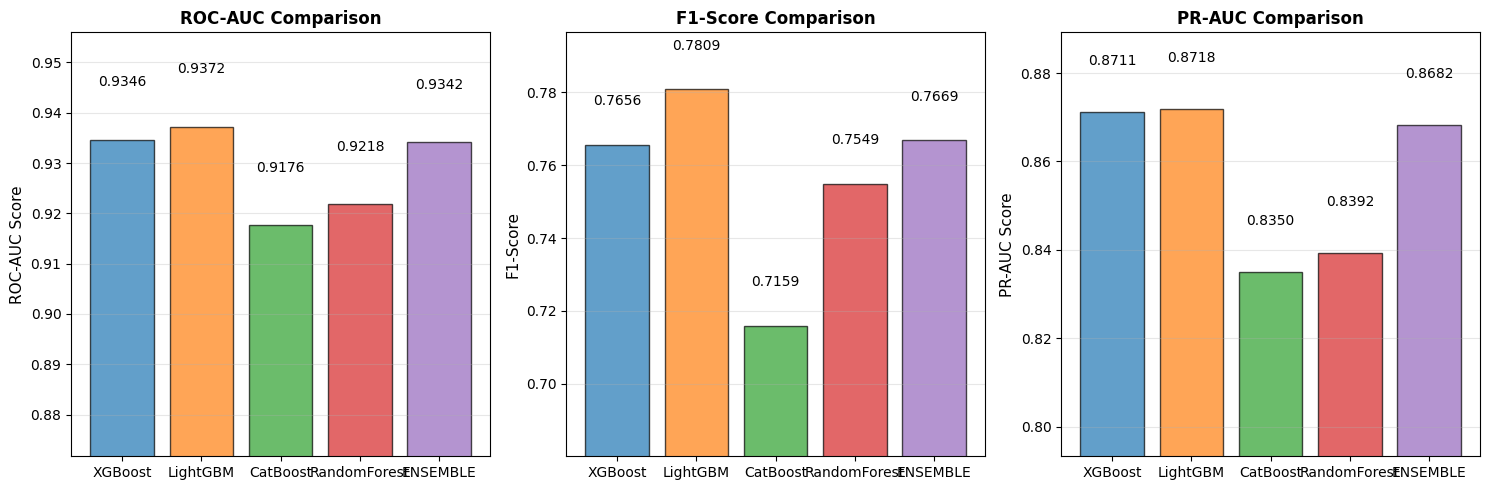


ENSEMBLE PIPELINE COMPLETE!


In [ ]:
print("\n" + "="*80)
print("FINAL ENSEMBLE PERFORMANCE SUMMARY")
print("="*80)

# Create summary table
summary_data = []
for model_name in ['XGBoost', 'LightGBM', 'CatBoost', 'RandomForest']:
    summary_data.append({
        'Model': model_name,
        'ROC-AUC': evaluation_results[model_name]['ROC-AUC'],
        'F1-Score': evaluation_results[model_name]['F1-Score'],
        'PR-AUC': evaluation_results[model_name]['PR-AUC']
    })

summary_data.append({
    'Model': 'ENSEMBLE',
    'ROC-AUC': ensemble_auc,
    'F1-Score': ensemble_f1,
    'PR-AUC': ensemble_pr_auc
})

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

# Visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ROC-AUC
ax = axes[0]
models = summary_df['Model'].tolist()
auc_scores = summary_df['ROC-AUC'].tolist()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
bars = ax.bar(models, auc_scores, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('ROC-AUC Score', fontsize=11)
ax.set_title('ROC-AUC Comparison', fontsize=12, fontweight='bold')
ax.set_ylim([min(auc_scores) * 0.95, max(auc_scores) * 1.02])
for i, v in enumerate(auc_scores):
    ax.text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontsize=10)
ax.grid(axis='y', alpha=0.3)

# F1-Score
ax = axes[1]
f1_scores = summary_df['F1-Score'].tolist()
bars = ax.bar(models, f1_scores, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('F1-Score', fontsize=11)
ax.set_title('F1-Score Comparison', fontsize=12, fontweight='bold')
ax.set_ylim([min(f1_scores) * 0.95, max(f1_scores) * 1.02])
for i, v in enumerate(f1_scores):
    ax.text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontsize=10)
ax.grid(axis='y', alpha=0.3)

# PR-AUC
ax = axes[2]
pr_auc_scores = summary_df['PR-AUC'].tolist()
bars = ax.bar(models, pr_auc_scores, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('PR-AUC Score', fontsize=11)
ax.set_title('PR-AUC Comparison', fontsize=12, fontweight='bold')
ax.set_ylim([min(pr_auc_scores) * 0.95, max(pr_auc_scores) * 1.02])
for i, v in enumerate(pr_auc_scores):
    ax.text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("ENSEMBLE PIPELINE COMPLETE!")
print("="*80)



## STACKED ENSEMBLE: META MODEL LAYER

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score
from sklearn.model_selection import StratifiedKFold
import time
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("STACKED ENSEMBLE: OUT-OF-FOLD (OOF) META-MODEL TRAINING")
print("="*80)
print("\nBUG 1 FIX: Implementing proper OOF stacking to prevent data leakage")
print("Step 1: Generate OOF predictions on training set using 5-fold CV")
print("Step 2: Train meta-model on OOF predictions")
print("Step 3: Evaluate meta-model on holdout set predictions\n")

# ============================================================================
# STEP 1: Generate Out-of-Fold (OOF) Predictions on Training Set
# ============================================================================

print("="*80)
print("GENERATING OOF PREDICTIONS FROM BASE MODELS")
print("="*80 + "\n")

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=11)

# Initialize OOF prediction arrays for each base model
n_train = len(X_train_standard)
n_classes = len(np.unique(y_train_final))

oof_predictions = {
    'XGBoost': np.zeros((n_train, n_classes)),
    'LightGBM': np.zeros((n_train, n_classes)),
    'CatBoost': np.zeros((n_train, n_classes)),
    'RandomForest': np.zeros((n_train, n_classes))
}

print(f"Training set size: {n_train}")
print(f"Number of folds: {n_splits}")
print(f"Number of classes: {n_classes}\n")

# Generate OOF predictions for each base model
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train_standard, y_train_final)):
    print(f"Processing Fold {fold_idx + 1}/{n_splits}...")
    
    # Split data for this fold
    X_fold_train = X_train_standard.iloc[train_idx]
    X_fold_val = X_train_standard.iloc[val_idx]
    y_fold_train = y_train_final.iloc[train_idx]
    y_fold_val = y_train_final.iloc[val_idx]
    
    # CatBoost data
    X_fold_train_cb = X_train_catboost.iloc[train_idx]
    X_fold_val_cb = X_train_catboost.iloc[val_idx]
    
    # Train each base model on this fold and predict on validation
    for model_name in ['XGBoost', 'LightGBM', 'CatBoost', 'RandomForest']:
        # Get the trained model's parameters
        base_params = best_params_dict[model_name].copy()
        
        if model_name == 'XGBoost':
            from xgboost import XGBClassifier
            params = strip_prefix(base_params, "xgb_")
            params.pop("early_stopping_rounds", None)
            params["random_state"] = RANDOM_SEED
            params["eval_metric"] = "mlogloss"
            params["verbosity"] = 0
            params["n_jobs"] = -1
            if gpu_available:
                params["device"] = f"cuda:{gpu_id}"
                params["tree_method"] = "hist"
            
            fold_model = XGBClassifier(**params)
            sw_fold = get_sample_weights(y_fold_train.values)
            fold_model.fit(X_fold_train, y_fold_train, sample_weight=sw_fold)
            oof_predictions[model_name][val_idx] = fold_model.predict_proba(X_fold_val)
            
        elif model_name == 'LightGBM':
            from lightgbm import LGBMClassifier
            params = strip_prefix(base_params, "lgb_")
            params.pop("early_stopping_rounds", None)
            params["random_state"] = RANDOM_SEED
            params["verbose"] = -1
            params["n_jobs"] = -1
            params["subsample_freq"] = 1
            params["class_weight"] = get_class_weight_dict(y_fold_train.values)
            if gpu_available:
                params["device"] = "gpu"
                params["gpu_device_id"] = gpu_id
            
            fold_model = LGBMClassifier(**params)
            fold_model.fit(X_fold_train, y_fold_train)
            oof_predictions[model_name][val_idx] = fold_model.predict_proba(X_fold_val)
            
        elif model_name == 'CatBoost':
            from catboost import CatBoostClassifier
            params = strip_prefix(base_params, "cb_")
            params.pop("early_stopping_rounds", None)
            params["random_seed"] = RANDOM_SEED
            params["verbose"] = False
            params["thread_count"] = -1
            params["auto_class_weights"] = "Balanced"
            params["loss_function"] = "MultiClass"
            params["bootstrap_type"] = "Poisson" if gpu_available else "Bernoulli"
            if gpu_available:
                params["task_type"] = "GPU"
                params["devices"] = str(gpu_id)
            
            fold_model = CatBoostClassifier(**params)
            fold_model.fit(
                X_fold_train_cb.values,
                y_fold_train,
                cat_features=cat_feature_indices_catboost,
                verbose=False
            )
            oof_predictions[model_name][val_idx] = fold_model.predict_proba(X_fold_val_cb.values)
            
        elif model_name == 'RandomForest':
            from sklearn.ensemble import RandomForestClassifier
            params = strip_prefix(base_params, "rf_")
            params["random_state"] = RANDOM_SEED
            params["bootstrap"] = True
            params["n_jobs"] = -1
            
            fold_model = RandomForestClassifier(**params)
            sw_fold = get_sample_weights(y_fold_train.values)
            fold_model.fit(
                X_fold_train.values.astype("float32"),
                y_fold_train.values.astype("int32"),
                sample_weight=sw_fold
            )
            oof_predictions[model_name][val_idx] = fold_model.predict_proba(X_fold_val.values.astype("float32"))
    
    print(f"  ✓ Fold {fold_idx + 1} complete\n")

print("="*80)
print("OOF PREDICTIONS GENERATED SUCCESSFULLY")
print("="*80 + "\n")

# Verify OOF predictions
for model_name, oof_preds in oof_predictions.items():
    oof_auc = roc_auc_score(y_train_final, oof_preds, multi_class='ovr', average='macro')
    print(f"{model_name:15s} OOF ROC-AUC: {oof_auc:.4f}")

# ============================================================================
# STEP 2: Create Meta-Features from OOF Predictions
# ============================================================================

print("\n" + "="*80)
print("CREATING META-FEATURES")
print("="*80 + "\n")

# Stack OOF predictions column-wise to create meta-training features
# Option 1: Use class probabilities (n_samples, n_models * n_classes)
X_meta_train_oof = np.hstack([
    oof_predictions['XGBoost'],
    oof_predictions['LightGBM'],
    oof_predictions['CatBoost'],
    oof_predictions['RandomForest']
])
y_meta_train_oof = y_train_final.values

print(f"Meta-training features shape: {X_meta_train_oof.shape}")
print(f"Meta-training target shape: {y_meta_train_oof.shape}")
print(f"Target distribution: {np.bincount(y_meta_train_oof)}\n")

# Create meta-test features from holdout predictions
X_meta_holdout = np.hstack([
    evaluation_results['XGBoost']['y_pred_proba'],
    evaluation_results['LightGBM']['y_pred_proba'],
    evaluation_results['CatBoost']['y_pred_proba'],
    evaluation_results['RandomForest']['y_pred_proba']
])
y_meta_holdout = y_holdout_final.values

print(f"Meta-holdout features shape: {X_meta_holdout.shape}")
print(f"Meta-holdout target shape: {y_meta_holdout.shape}")

# ============================================================================
# STEP 3: Train and Evaluate Meta-Models
# ============================================================================

print("\n" + "="*80)
print("TRAINING META-MODELS ON OOF PREDICTIONS")
print("="*80 + "\n")

# Define candidate meta models
meta_models = {
    'Logistic_Regression': LogisticRegression(
        max_iter=1000,
        random_state=11,
        solver='lbfgs',
        class_weight='balanced'
    ),
    'Random_Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=11,
        class_weight='balanced',
        n_jobs=-1
    ),
    'Gradient_Boosting': GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=11,
        subsample=0.8
    ),
    'MLP_Classifier': MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        batch_size=32,
        max_iter=300,
        learning_rate_init=0.001,
        random_state=11,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        verbose=False
    )
}

# Train and evaluate all meta models
meta_results = {}
best_model_name = None
best_auc = -1

for model_name, model in meta_models.items():
    print(f"Training {model_name}...")
    start_time = time.time()

    try:
        # Train meta model on OOF predictions
        model.fit(X_meta_train_oof, y_meta_train_oof)
        train_time = time.time() - start_time

        # Evaluate on HOLDOUT set (not training set!)
        y_meta_pred_proba = model.predict_proba(X_meta_holdout)
        y_meta_pred = model.predict(X_meta_holdout)

        # Calculate metrics on holdout
        auc = roc_auc_score(y_meta_holdout, y_meta_pred_proba, multi_class='ovr', average='macro')
        f1 = f1_score(y_meta_holdout, y_meta_pred, average='macro')
        precision = precision_score(y_meta_holdout, y_meta_pred, average='macro', zero_division=0)
        recall = recall_score(y_meta_holdout, y_meta_pred, average='macro', zero_division=0)
        accuracy = accuracy_score(y_meta_holdout, y_meta_pred)

        # Store results
        meta_results[model_name] = {
            'model': model,
            'auc': auc,
            'f1': f1,
            'precision': precision,
            'recall': recall,
            'accuracy': accuracy,
            'train_time': train_time,
            'y_pred_proba': y_meta_pred_proba,
            'y_pred': y_meta_pred
        }

        # Track best model
        if auc > best_auc:
            best_auc = auc
            best_model_name = model_name

        print(f"  ✓ Holdout AUC: {auc:.4f} | F1: {f1:.4f} | Accuracy: {accuracy:.4f} | Time: {train_time:.2f}s\n")

    except Exception as e:
        print(f"  ✗ Error: {str(e)}\n")
        continue

# Display comprehensive results
print("="*80)
print("META MODEL COMPARISON (EVALUATED ON HOLDOUT SET)")
print("="*80 + "\n")

results_df = pd.DataFrame({
    'Model': list(meta_results.keys()),
    'ROC-AUC': [meta_results[m]['auc'] for m in meta_results],
    'F1-Score': [meta_results[m]['f1'] for m in meta_results],
    'Precision': [meta_results[m]['precision'] for m in meta_results],
    'Recall': [meta_results[m]['recall'] for m in meta_results],
    'Accuracy': [meta_results[m]['accuracy'] for m in meta_results],
    'Train_Time(s)': [meta_results[m]['train_time'] for m in meta_results],
})

results_df = results_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

print("\n" + "="*80)
print(f"BEST META MODEL: {best_model_name}")
print("="*80)
best_metrics = meta_results[best_model_name]
print(f"Holdout ROC-AUC: {best_metrics['auc']:.4f}")
print(f"Holdout F1-Score: {best_metrics['f1']:.4f}")
print(f"Holdout Precision: {best_metrics['precision']:.4f}")
print(f"Holdout Recall: {best_metrics['recall']:.4f}")
print(f"Holdout Accuracy: {best_metrics['accuracy']:.4f}")
print(f"Training time: {best_metrics['train_time']:.2f}s")
print("\n⚠ NOTE: These are VALID metrics - meta-model trained on OOF, evaluated on holdout\n")

# Store best meta model
best_meta_model       = meta_results[best_model_name]['model']
best_meta_predictions = meta_results[best_model_name]['y_pred_proba']

print(f"✓ Best meta model selected and ready for final predictions")

STACKED ENSEMBLE: META MODEL SELECTION
Input shape: Base model predictions (63000, 3)

Meta-features shape: (63000, 3)
Target distribution: [36992 23907  2101]

TRAINING META MODELS ON SOFT VOTING PREDICTIONS

Training Logistic_Regression...
  ✓ AUC: 0.9287 | F1: 0.7476 | Accuracy: 0.8010 | Time: 0.24s

Training Random_Forest...
  ✓ AUC: 0.9427 | F1: 0.7859 | Accuracy: 0.8207 | Time: 1.49s

Training Gradient_Boosting...
  ✓ AUC: 0.9471 | F1: 0.8181 | Accuracy: 0.8361 | Time: 29.68s

Training MLP_Classifier...
  ✓ AUC: 0.9382 | F1: 0.7898 | Accuracy: 0.8225 | Time: 95.63s

META MODEL COMPARISON

              Model  ROC-AUC  F1-Score  Precision   Recall  Accuracy  Train_Time(s)
  Gradient_Boosting 0.947148  0.818145   0.837704 0.801249  0.836079      29.677465
      Random_Forest 0.942651  0.785905   0.744498 0.856152  0.820714       1.494205
     MLP_Classifier 0.938152  0.789826   0.804527 0.776818  0.822476      95.625399
Logistic_Regression 0.928708  0.747572   0.704949 0.834814  0.